In [1]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
import time
import os
from scipy.optimize import curve_fit
import B00_codes.dataReader as dr
from mpl_toolkits.axes_grid1 import make_axes_locatable
import math
import matplotlib.colors as mcolors
import json
from scipy.special import jn
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.cm as cm
from matplotlib.colors import LinearSegmentedColormap
from lmfit import Model, Parameters, minimize
from scipy.integrate import dblquad
from matplotlib.colors import to_rgba
pi = np.pi
plt.rcParams["font.family"] = "Arial"
plt.rcParams['svg.fonttype'] = 'none'

def get_dissipative_part(rho, L1, L2):
        """
        Both L1 and L2 are Hermitian
        """
        C = rho @ L2
        C_dagger = C.conj().T
        C = C - C_dagger #computes [rho, L2]
        C = L1 @ C
        C_dagger = C.conj().T

        return 0.5 * (C + C_dagger)

def Dyn_rho_2qubits(t, rho_vec, 
                    H, L, gamma_d, sigma_1z, sigma_2z):
    rho = np.reshape(rho_vec, (4, 4))

    #coherent part
    C = H @ rho
    C_dagger = C.conj().T
    drhodt = - 1j * (C - C_dagger)

    #Correlated dissipation 
    drhodt += get_dissipative_part(rho, L, L) + \
        gamma_d[0, 0] * get_dissipative_part(rho, sigma_1z, sigma_1z) + \
        gamma_d[0, 1] * get_dissipative_part(rho, sigma_1z, sigma_2z) + \
        gamma_d[1, 0] * get_dissipative_part(rho, sigma_2z, sigma_1z) + \
        gamma_d[1, 1] * get_dissipative_part(rho, sigma_2z, sigma_2z)
        

    return drhodt.flatten()

sigma_mn = np.array([[0, 0], [1, 0]])
sigma_z = np.array([[1, 0], [0, -1]])
sigma_x = np.array([[0, 1], [1, 0]])
sigma_y = np.array([[0, -1j], [1j, 0]])

sigma_1mn = np.kron(np.eye(2), sigma_mn)
sigma_1pl = sigma_1mn.T

sigma_2mn = np.kron(sigma_mn, np.eye(2))
sigma_2pl = sigma_2mn.T

sigma_1z = np.kron(np.eye(2), sigma_z)
sigma_2z = np.kron(sigma_z, np.eye(2))

sigma_1x = np.kron(np.eye(2), sigma_x)
sigma_2x = np.kron(sigma_x, np.eye(2))

sigma_1y = np.kron(np.eye(2), sigma_y)
sigma_2y = np.kron(sigma_y, np.eye(2))

phi1 = np.array([1, 0, 0, 0], dtype=complex)#symmetric up-up state
phi2 = np.array([0, 1 / np.sqrt(2), 1 / np.sqrt(2), 0], dtype=complex)#symmetric up-dn state
phi3 = np.array([0, 0, 0, 1], dtype=complex)#symmetric dn-dn state
psi = np.array([0, 1 / np.sqrt(2), -1 / np.sqrt(2), 0], dtype=complex)#anti-symmetric up-dn state
 
pi = np.pi

In [2]:
#Parameters
delta_1z = 0.5*2*pi #detuning on NV_1
delta_2z = 0.0*2*pi       #detuning on NV_2
phi = -pi/2
amp_1 = 1.012 * np.exp(1j * phi)#using the same notations as in single_qubit simulations
amp_2 = 1.115 * np.exp(1j * phi)#using the same notations as in single_qubit simulations
tau_c = 0.1; Tmax=3000

Gamma_1 = 2 * (2 * np.pi)**0.5 * tau_c * np.abs(amp_1)**2
Gamma_2 = 2 * (2 * np.pi)**0.5 * tau_c * np.abs(amp_2)**2

gamma_d_11 = 0.5
gamma_d_22 = gamma_d_11
gamma_d_12 = 0.4 #should be real, represents correlated dephasing
gamma_d = np.array([[gamma_d_11, gamma_d_12], [gamma_d_12, gamma_d_22]])#dephasing matrix

t_span = [0, Tmax] 
t_eval = np.logspace(-2, np.log10(Tmax), 5000); t_eval[-1]=Tmax

H = 0.5 * delta_1z * sigma_1z + 0.5 * delta_2z * sigma_2z
L = (2 * np.pi)**0.25 * np.sqrt(tau_c) * (
    amp_1 * sigma_1pl + np.conjugate(amp_1) * sigma_1mn +
    amp_2 * sigma_2pl + np.conjugate(amp_2) * sigma_2mn
       )


# Solving QME

In [1120]:
rho = np.array([[1, 0, 0, 0], 
                [0, 0, 0, 0], 
                [0, 0, 0, 0], 
                [0, 0, 0, 0]],dtype=complex)
rho_vec = rho.flatten()


solution = solve_ivp(lambda t, y: Dyn_rho_2qubits(t, y, H, L, gamma_d, sigma_1z, sigma_2z), 
                     t_span=t_span, 
                     y0=rho_vec, 
                     t_eval=t_eval,  # specify the evaluation points
                     method='RK45', 
                     atol=1e-10, 
                     rtol=1e-10)


sz1_t = np.zeros_like(t_eval, dtype=complex)
sz2_t = np.zeros_like(t_eval, dtype=complex)
sz1sz2_t = np.zeros_like(t_eval, dtype=complex)
ent_entropy_t = np.zeros_like(t_eval, dtype=complex)
threshold = 1e-10

sx1_t = np.zeros_like(t_eval, dtype=complex)
sx2_t = np.zeros_like(t_eval, dtype=complex)
sy1_t = np.zeros_like(t_eval, dtype=complex)
sy2_t = np.zeros_like(t_eval, dtype=complex)

sx1sy1_t = np.zeros_like(t_eval, dtype=complex)
sx1sz1_t = np.zeros_like(t_eval, dtype=complex)
sy1sx1_t = np.zeros_like(t_eval, dtype=complex)

prob_psi = np.zeros_like(t_eval, dtype=complex)
prob_phi1 = np.zeros_like(t_eval, dtype=complex)
prob_phi2 = np.zeros_like(t_eval, dtype=complex)
prob_phi3 = np.zeros_like(t_eval, dtype=complex)

for ind_t in range(len(t_eval)):
    rho_t = np.reshape(solution.y[:,ind_t], (4, 4))
    sz1_t[ind_t] = np.trace(sigma_1z @ rho_t)
    sz2_t[ind_t] = np.trace(sigma_2z @ rho_t)
    sz1sz2_t[ind_t] = np.trace(sigma_1z @ sigma_2z @ rho_t) - sz1_t[ind_t] * sz2_t[ind_t]

    eigenvalues, eigenvectors = np.linalg.eigh(rho_t)
    
    significant_eigenvalues = eigenvalues[eigenvalues > threshold]
    if significant_eigenvalues.size > 0:
        ent_entropy_t[ind_t] = -np.sum(significant_eigenvalues * np.log2(significant_eigenvalues))

    prob_psi[ind_t] = psi.conj().T @ rho_t @ psi
    prob_phi1[ind_t] = phi1.conj().T @ rho_t @ phi1
    prob_phi2[ind_t] = phi2.conj().T @ rho_t @ phi2
    prob_phi3[ind_t] = phi3.conj().T @ rho_t @ phi3

    sx1_t[ind_t] = np.trace(sigma_1x @ rho_t)
    sx2_t[ind_t] = np.trace(sigma_2x @ rho_t)
    sy1_t[ind_t] = np.trace(sigma_1y @ rho_t)
    sy2_t[ind_t] = np.trace(sigma_2y @ rho_t)

    sx1sy1_t[ind_t] = np.trace(sigma_1x @ sigma_1y @ rho_t)
    sy1sx1_t[ind_t] = np.trace(sigma_1y @ sigma_1x @ rho_t)

    sx1sz1_t[ind_t] = np.trace(sigma_1x @ sigma_1z @ rho_t)

C:\Users\lukin2dmaterials\AppData\Roaming\Python\Python310\site-packages\matplotlib\cbook.py:1762: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
C:\Users\lukin2dmaterials\AppData\Roaming\Python\Python310\site-packages\matplotlib\cbook.py:1398: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


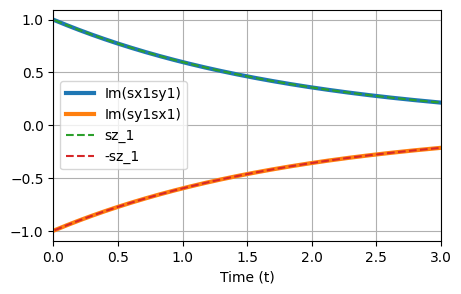

In [1121]:
plt.figure(figsize=(5,3))

plt.plot(t_eval, np.imag(sx1sy1_t), label='Im(sx1sy1)', linewidth=3)
plt.plot(t_eval, np.imag(sy1sx1_t), label='Im(sy1sx1)', linewidth=3)

plt.plot(t_eval, sz1_t, label='sz_1', linestyle='--')
plt.plot(t_eval, -sz1_t, label='-sz_1', linestyle='--')

plt.xlabel('Time (t)')
plt.xlim(0, 3)
plt.grid(True)
plt.legend()
plt.show()

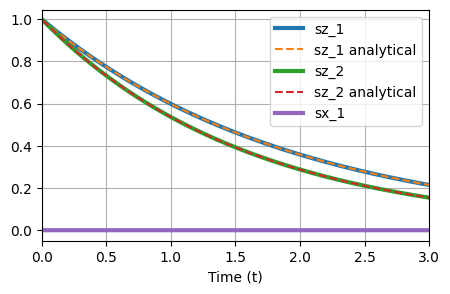

In [1122]:
plt.figure(figsize=(5,3))
plt.plot(t_eval, sz1_t, label='sz_1', linewidth=3)
plt.plot(t_eval, np.exp(- Gamma_1 * t_eval), label='sz_1 analytical', linestyle='--')

plt.plot(t_eval, sz2_t, label='sz_2', linewidth=3)
plt.plot(t_eval, np.exp(- Gamma_2 * t_eval), label='sz_2 analytical', linestyle='--')

plt.plot(t_eval, sy2_t, label='sx_1', linewidth=3)

plt.xlabel('Time (t)')
plt.xlim(0, 3)
plt.grid(True)
plt.legend()
plt.show()

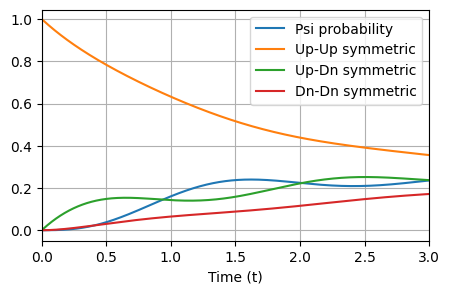

In [1123]:
plt.figure(figsize=(5,3))
plt.plot(t_eval, prob_psi, label='Psi probability')
plt.plot(t_eval, prob_phi1, label='Up-Up symmetric')
plt.plot(t_eval, prob_phi2, label='Up-Dn symmetric')
plt.plot(t_eval, prob_phi3, label='Dn-Dn symmetric')
plt.xlabel('Time (t)')
plt.xlim(0, 3)
plt.grid(True)
plt.legend()
plt.show()

# Including all effects, just matrix diagonalization

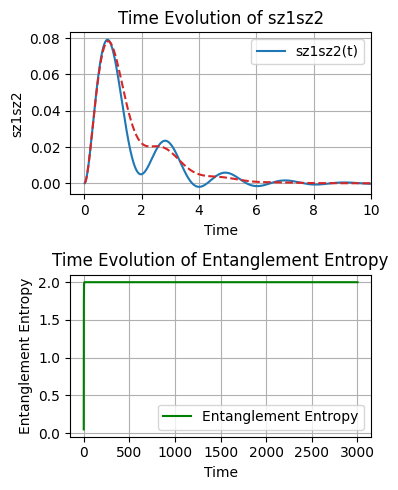

In [1170]:
Gamma_tot_r = Gamma_1 + Gamma_2
Gamma_tot_d = 2 * gamma_d_11 + 2 * gamma_d_22
Gamma_tot = Gamma_tot_r + Gamma_tot_d

Mat = np.array([[- Gamma_tot_r, 2 * np.sqrt(Gamma_1 * Gamma_2), 0, 0, 0],
                 [2 * np.sqrt(Gamma_1 * Gamma_2), - Gamma_tot,  4 * gamma_d_12, delta_1z, delta_2z],
                 [0, 4 * gamma_d_12, - Gamma_tot_d, - delta_2z, - delta_1z],
                 [0, - delta_1z, delta_2z, - (Gamma_2 + Gamma_tot_d), - 4 * gamma_d_12],
                 [0, - delta_2z, delta_1z, - 4 * gamma_d_12, - (Gamma_1 + Gamma_tot_d)]])


eigenvalues, eigenvectors = np.linalg.eig(Mat)
normalized_eigenvectors = eigenvectors / np.linalg.norm(eigenvectors, axis=0)
initial_vector = np.array([1, 0, 0, 0, 0])
coefficients = np.linalg.inv(normalized_eigenvectors).dot(initial_vector)

analytical = coefficients[0] * np.exp(eigenvalues[0] * t_eval) * normalized_eigenvectors[0, 0] +\
    coefficients[1] * np.exp(eigenvalues[1] * t_eval) * normalized_eigenvectors[0, 1] +\
    coefficients[2] * np.exp(eigenvalues[2] * t_eval) * normalized_eigenvectors[0, 2] +\
    coefficients[3] * np.exp(eigenvalues[3] * t_eval) * normalized_eigenvectors[0, 3] +\
    coefficients[4] * np.exp(eigenvalues[4] * t_eval) * normalized_eigenvectors[0, 4] -\
    np.exp(- (Gamma_1 + Gamma_2) * t_eval)
if True:
    # ####THIS APPLIES FOR NO DETUNING
    # Mat = np.array([[- Gamma_tot_r, 2 * np.sqrt(Gamma_1 * Gamma_2), 0],
    #                 [2 * np.sqrt(Gamma_1 * Gamma_2), - Gamma_tot,  4 * gamma_d_12],
    #                 [0, 4 * gamma_d_12, - Gamma_tot_d]])

    # lambdas = np.linalg.eigvals(Mat)

    # A, B, C = np.linalg.inv(np.vander(lambdas, increasing=True).T) @ np.array([[1],[-Gamma_tot_r],[Gamma_tot_r**2 + 4 * Gamma_1 * Gamma_2]])
    # analytical = A[0] * np.exp(lambdas[0] * t_eval) \
    #     + B[0] * np.exp(lambdas[1] * t_eval) \
    #         + C[0] * np.exp(lambdas[2] * t_eval) \
    #             - np.exp(- (Gamma_1 + Gamma_2) * t_eval)


    fig, axs = plt.subplots(2, 1, figsize=(4,5))
    axs[0].plot(t_eval, sz1sz2_t, label='sz1sz2(t)', color='C0')
    # axs[0].plot(t_eval, (np.cosh(2 * t_eval * np.sqrt(Gamma_1 * Gamma_2)) - 1) * np.exp(- (Gamma_1 + Gamma_2) * t_eval), linestyle='--')
    axs[0].plot(t_eval, analytical, linestyle='--',color='C3')
    axs[0].set_title('Time Evolution of sz1sz2')
    axs[0].set_xlabel('Time')
    axs[0].set_xlim(-0.5,10)
    axs[0].set_ylabel('sz1sz2')
    axs[0].legend()
    axs[0].grid(True)

    axs[1].plot(t_eval, ent_entropy_t, label='Entanglement Entropy', color='green')
    axs[1].set_title('Time Evolution of Entanglement Entropy')
    axs[1].set_xlabel('Time')
    axs[1].set_ylabel('Entanglement Entropy')
    axs[1].legend()
    axs[1].grid(True)

    # Adjust the layout so the plots do not overlap
    plt.tight_layout()

    # Display the plot
    plt.show()

# Global fit the data

In [26]:
folder = 'C:/Users/lukin2dmaterials/data/forDeliv/'
file = 'T1SCCRRNoise_batch33_corr_thres25.txt'; path = folder + file; loaded = np.loadtxt(path)
x=loaded[:,0]; ys=loaded[:,1]; yr=loaded[:,2]; errs=loaded[:,3]; errr=loaded[:,4]
idx = np.argsort(x)
x=x[idx]; ys=ys[idx]; yr=yr[idx]; errs=errs[idx]; errr=errr[idx]

file = 'T1SCCRRNoise_batch2425263132_cleaned.txt'; path = folder + file; loaded = np.loadtxt(path)
x2=loaded[:,0]; y2=loaded[:,1]; err2=loaded[:,2]
idx = np.argsort(x2)
x2=x2[idx]; y2=y2[idx]; err2=err2[idx]
x2[6] = 0.6; x2[7] = 0.64

file = 'T1SCCRRNoise_batch181920b_corr_thres.txt'; path = folder + file; loaded = np.loadtxt(path)
x0 = loaded[:,0]; ys0 = loaded[:,1]; errs0 = loaded[:,2]
idx = np.argsort(x0)
x0=x0[idx]; ys0=ys0[idx]; errs0=errs0[idx]
file = 'T1SCCRRNoise_batch20a21a_acorr_thres.txt'; path = folder + file; loaded = np.loadtxt(path)
xr0 = loaded[:,0]; yr0 = loaded[:,1]; errr0 = loaded[:,2]
idx = np.argsort(xr0)
xr0=xr0[idx]; yr0=yr0[idx]; errr0=errr0[idx]

y = ((ys/errs**2) - (yr/errr**2))/((1/errs**2) + (1/errr**2))    
err = np.sqrt(1/((1/errs**2) + (1/errr**2)))

y0 = ((ys0/errs0**2) - (yr0/errr0**2))/((1/errs0**2) + (1/errr0**2))    
err0 = np.sqrt(1/((1/errs0**2) + (1/errr0**2)))

t_eval = x; t_eval0 = x0; t_eval2 = x2


### Fitted detuning

In [1126]:
def f(t_eval, A, Gamma_tot_d, gamma_d_12, d1a, d2a):
    #Parameters
    delta_1z = d1a*2*pi #detuning on NV_1
    delta_2z = d2a*2*pi #detuning on NV_2
    phi = -pi/2
    amp_1 = 1.012 * np.exp(1j * phi)#using the same notations as in single_qubit simulations
    amp_2 = 1.115 * np.exp(1j * phi)#using the same notations as in single_qubit simulations
    tau_c = 0.1

    Gamma_1 = 2 * (2 * np.pi)**0.5 * tau_c * np.abs(amp_1)**2
    Gamma_2 = 2 * (2 * np.pi)**0.5 * tau_c * np.abs(amp_2)**2

    Gamma_tot_r = Gamma_1 + Gamma_2
    Gamma_tot = Gamma_tot_r + Gamma_tot_d

    Mat = np.array([[- Gamma_tot_r, 2 * np.sqrt(Gamma_1 * Gamma_2), 0, 0, 0],
                    [2 * np.sqrt(Gamma_1 * Gamma_2), - Gamma_tot,  4 * gamma_d_12, delta_1z, delta_2z],
                    [0, 4 * gamma_d_12, - Gamma_tot_d, - delta_2z, - delta_1z],
                    [0, - delta_1z, delta_2z, - (Gamma_2 + Gamma_tot_d), - 4 * gamma_d_12],
                    [0, - delta_2z, delta_1z, - 4 * gamma_d_12, - (Gamma_1 + Gamma_tot_d)]])

    eigenvalues, eigenvectors = np.linalg.eig(Mat)
    normalized_eigenvectors = eigenvectors / np.linalg.norm(eigenvectors, axis=0)
    initial_vector = np.array([1, 0, 0, 0, 0])
    coefficients = np.linalg.inv(normalized_eigenvectors).dot(initial_vector)

    analytical = coefficients[0] * np.exp(eigenvalues[0] * t_eval) * normalized_eigenvectors[0, 0] +\
        coefficients[1] * np.exp(eigenvalues[1] * t_eval) * normalized_eigenvectors[0, 1] +\
        coefficients[2] * np.exp(eigenvalues[2] * t_eval) * normalized_eigenvectors[0, 2] +\
        coefficients[3] * np.exp(eigenvalues[3] * t_eval) * normalized_eigenvectors[0, 3] +\
        coefficients[4] * np.exp(eigenvalues[4] * t_eval) * normalized_eigenvectors[0, 4] -\
        np.exp(- (Gamma_1 + Gamma_2) * t_eval)
    # print('done f')
    return A*analytical.real

def f0(t_eval, A, Gamma_tot_d, gamma_d_12):
    #Parameters
    delta_1z = 0*2*pi #detuning on NV_1
    delta_2z = 0*2*pi #detuning on NV_2
    phi = -pi/2
    amp_1 = 1.012 * np.exp(1j * phi)#using the same notations as in single_qubit simulations
    amp_2 = 1.115 * np.exp(1j * phi)#using the same notations as in single_qubit simulations
    tau_c = 0.1

    Gamma_1 = 2 * (2 * np.pi)**0.5 * tau_c * np.abs(amp_1)**2
    Gamma_2 = 2 * (2 * np.pi)**0.5 * tau_c * np.abs(amp_2)**2

    Gamma_tot_r = Gamma_1 + Gamma_2
    Gamma_tot = Gamma_tot_r + Gamma_tot_d

    Mat = np.array([[- Gamma_tot_r, 2 * np.sqrt(Gamma_1 * Gamma_2), 0, 0, 0],
                    [2 * np.sqrt(Gamma_1 * Gamma_2), - Gamma_tot,  4 * gamma_d_12, delta_1z, delta_2z],
                    [0, 4 * gamma_d_12, - Gamma_tot_d, - delta_2z, - delta_1z],
                    [0, - delta_1z, delta_2z, - (Gamma_2 + Gamma_tot_d), - 4 * gamma_d_12],
                    [0, - delta_2z, delta_1z, - 4 * gamma_d_12, - (Gamma_1 + Gamma_tot_d)]])

    eigenvalues, eigenvectors = np.linalg.eig(Mat)
    normalized_eigenvectors = eigenvectors / np.linalg.norm(eigenvectors, axis=0)
    initial_vector = np.array([1, 0, 0, 0, 0])
    coefficients = np.linalg.inv(normalized_eigenvectors).dot(initial_vector)

    analytical = coefficients[0] * np.exp(eigenvalues[0] * t_eval) * normalized_eigenvectors[0, 0] +\
        coefficients[1] * np.exp(eigenvalues[1] * t_eval) * normalized_eigenvectors[0, 1] +\
        coefficients[2] * np.exp(eigenvalues[2] * t_eval) * normalized_eigenvectors[0, 2] +\
        coefficients[3] * np.exp(eigenvalues[3] * t_eval) * normalized_eigenvectors[0, 3] +\
        coefficients[4] * np.exp(eigenvalues[4] * t_eval) * normalized_eigenvectors[0, 4] -\
        np.exp(- (Gamma_1 + Gamma_2) * t_eval)
    # print('done f0')
    return A*analytical.real

def f2(t_eval, A, Gamma_tot_d, gamma_d_12, d1b, d2b):
    #Parameters
    delta_1z = d1b*2*pi #detuning on NV_1
    delta_2z = d2b*2*pi #detuning on NV_2
    phi = -pi/2
    amp_1 = 1.012 * np.exp(1j * phi)#using the same notations as in single_qubit simulations
    amp_2 = 1.115 * np.exp(1j * phi)#using the same notations as in single_qubit simulations
    tau_c = 0.1

    Gamma_1 = 2 * (2 * np.pi)**0.5 * tau_c * np.abs(amp_1)**2
    Gamma_2 = 2 * (2 * np.pi)**0.5 * tau_c * np.abs(amp_2)**2

    Gamma_tot_r = Gamma_1 + Gamma_2
    Gamma_tot = Gamma_tot_r + Gamma_tot_d

    Mat = np.array([[- Gamma_tot_r, 2 * np.sqrt(Gamma_1 * Gamma_2), 0, 0, 0],
                    [2 * np.sqrt(Gamma_1 * Gamma_2), - Gamma_tot,  4 * gamma_d_12, delta_1z, delta_2z],
                    [0, 4 * gamma_d_12, - Gamma_tot_d, - delta_2z, - delta_1z],
                    [0, - delta_1z, delta_2z, - (Gamma_2 + Gamma_tot_d), - 4 * gamma_d_12],
                    [0, - delta_2z, delta_1z, - 4 * gamma_d_12, - (Gamma_1 + Gamma_tot_d)]])

    eigenvalues, eigenvectors = np.linalg.eig(Mat)
    normalized_eigenvectors = eigenvectors / np.linalg.norm(eigenvectors, axis=0)
    initial_vector = np.array([1, 0, 0, 0, 0])
    coefficients = np.linalg.inv(normalized_eigenvectors).dot(initial_vector)

    analytical = coefficients[0] * np.exp(eigenvalues[0] * t_eval) * normalized_eigenvectors[0, 0] +\
        coefficients[1] * np.exp(eigenvalues[1] * t_eval) * normalized_eigenvectors[0, 1] +\
        coefficients[2] * np.exp(eigenvalues[2] * t_eval) * normalized_eigenvectors[0, 2] +\
        coefficients[3] * np.exp(eigenvalues[3] * t_eval) * normalized_eigenvectors[0, 3] +\
        coefficients[4] * np.exp(eigenvalues[4] * t_eval) * normalized_eigenvectors[0, 4] -\
        np.exp(- (Gamma_1 + Gamma_2) * t_eval)
    # print('done f2')
    # print(analytical.real)
    return A*analytical.real

# Define objective function
def objective(params, t_eval0, t_eval, t_eval2, y0,y,y2):
    A = params['A'].value
    gd = params['Gamma_tot_d'].value
    gd12  = params['gamma_d_12'].value
    d1a  = params['d1a'].value
    d2a  = params['d2a'].value
    d1b  = params['d1b'].value
    d2b  = params['d2b'].value
    res0 = y0 - f0(t_eval0, A, gd, gd12)
    res  = y -  f(t_eval, A, gd, gd12, d1a, d2a)
    res2 = y2 - f2(t_eval2, A, gd, gd12, d1b, d2b)
    return np.concatenate((res0, res, res2))  # Combine residuals

# Define shared and unique parameters
if True:
    params = Parameters()
    params.add('A', value=0.05, min=0.03, max=0.07)
    params.add('Gamma_tot_d', value=1.52, min = 0,max=2)  
    params.add('gamma_d_12', value=0.35, min = 0, max=0.5)
    params.add('d1a', value=0.12, min = -0.5,max=0.5) 
    params.add('d1b', value=0.12, min = -0.5,max=0.5)
    params.add('d2a', value=0.12, min = -0.5,max=0.5)
    params.add('d2b', value=0.12, min = -0.5,max=0.5)

In [1127]:
# Fit data
if True:
    result = minimize(objective, params, args=(t_eval0, t_eval, t_eval2,  y0,y,y2))
    A = result.params['A'].value
    gd = result.params['Gamma_tot_d'].value; gd12 = result.params['gamma_d_12'].value
    d1a = result.params['d1a'].value; d1b = result.params['d1b'].value
    d2a = result.params['d2a'].value; d2b = result.params['d2b'].value
    fitted_params = np.array([A,gd,gd12,d1a, d2a, d1b, d2b])

    Aerr = result.params['A'].stderr
    gderr = result.params['Gamma_tot_d'].stderr; gd12err = result.params['gamma_d_12'].stderr
    d1aerr = result.params['d1a'].stderr; d1berr = result.params['d1b'].stderr
    d2aerr = result.params['d2a'].stderr; d2berr = result.params['d2b'].stderr
    fitted_params_err = np.array([Aerr,gderr,gd12err,d1aerr, d2aerr, d1berr, d2berr])

    if np.any(fitted_params_err == None):
        fitted_params_err = np.array([1e6,1e6,1e6,1e6,1e6,1e6,1e6])
    
    ratios = fitted_params_err/fitted_params*100
    # sums[i,j]=np.sum(ratios)

    # Print results
    print(result.params.pretty_print())
    print(ratios)
    print(np.sum(np.abs(ratios)))


Name            Value      Min      Max   Stderr     Vary     Expr Brute_Step
A             0.04575     0.03     0.07 0.005051     True     None     None
Gamma_tot_d    0.7807        0        2   0.3286     True     None     None
d1a           -0.1252     -0.5      0.5    2.407     True     None     None
d1b           0.03477     -0.5      0.5  0.07276     True     None     None
d2a            0.1199     -0.5      0.5    2.399     True     None     None
d2b           -0.4847     -0.5      0.5  0.04733     True     None     None
gamma_d_12     0.1325        0      0.5  0.08053     True     None     None
None
[   11.04090075    42.09101639    60.78542719 -1923.29715675
  2001.41736111   209.27925532    -9.7647526 ]
4257.675870121406


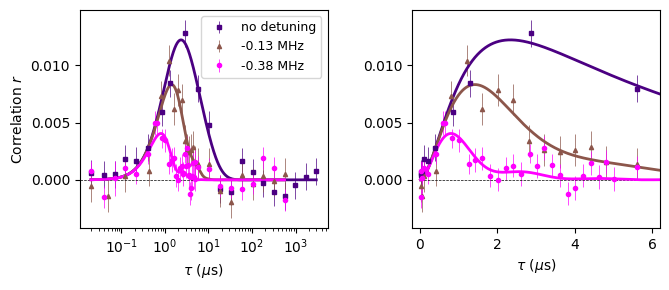

In [1128]:
fig, axs = plt.subplots(1,2,figsize=(7,3)); ifAntiCorr=1; idx=7; ifFit=0

xt0 = np.logspace(np.log10(x0[0]),np.log10(x0[-1]),10001)
xt= np.logspace(np.log10(x[0]),np.log10(x[-1]),10001)
xt2 = np.logspace(np.log10(x2[0]),np.log10(x2[-1]),10001)
yt0 = f0(xt0,A,gd, gd12); yt = f(xt,A,gd, gd12, d1a, d2a); yt2 = f2(xt2,A,gd, gd12, d1b, d2b)
# ###############################################################################################
if True:
    axs[0].errorbar(x0,y0,err0, marker='s',linewidth=0.0, elinewidth=0.5,
                    markersize=3, label='no detuning',color="#4B0082")
    axs[0].errorbar(x,y,err, marker='^',linewidth=0.0, elinewidth=0.5,
                    markersize=3, label='-0.13 MHz',color="C5")
    axs[0].errorbar(x2,y2,err2, marker='o',linewidth=0.0, elinewidth=0.5,
                    markersize=3, label='-0.38 MHz',color="magenta")
    axs[0].hlines(y=0,xmin=0,xmax=max(x0),linestyle='--',color='k',linewidth=0.5)
    axs[0].plot(xt0, yt0, linewidth=2, markersize=3, color="#4B0082",label=None)
    axs[0].plot(xt, yt, linewidth=2, markersize=3, color='C5',label=None)
    axs[0].plot(xt2, yt2, linewidth=2, markersize=3, color='magenta',label=None)

    axs[1].errorbar(x0,y0,err0, marker='s',linewidth=0.0, elinewidth=0.5,
                    markersize=3, label='no detuning',color="#4B0082")
    axs[1].errorbar(x,y,err, marker='^',linewidth=0.0, elinewidth=0.5,
                    markersize=3, label='-0.13 MHz',color="C5")
    axs[1].errorbar(x2,y2,err2, marker='o',linewidth=0.0, elinewidth=0.5,
                    markersize=3, label='-0.38 MHz',color="magenta",capsize=0)
    axs[1].hlines(y=0,xmin=0,xmax=max(x0),linestyle='--',color='k',linewidth=0.5)
    axs[1].plot(xt0, yt0, linewidth=2, markersize=3, color="#4B0082",label=None)
    axs[1].plot(xt, yt, linewidth=2, markersize=3, color='C5',label=None)
    axs[1].plot(xt2, yt2, linewidth=2, markersize=3, color='magenta',label=None)
    

    for i in range(2):
        axs[0].set_xscale('log')
        axs[1].set_xlim((-0.2,6.2))
        axs[i].set_xlabel('$\\tau$ ($\mu$s)')
        axs[0].set_ylabel('Correlation $r$')
        axs[0].legend(fontsize=9,loc='upper right')

    plt.tight_layout()

### Fix detuning

In [1724]:
# Fix detuning
def f(t_eval, A, Gamma_tot_d, gamma_d_12):
    #Parameters
    delta_1z = 0.25*2*pi #detuning on NV_1
    delta_2z = 0*2*pi #detuning on NV_2
    phi = -pi/2
    amp_1 = 1.012 * np.exp(1j * phi)#using the same notations as in single_qubit simulations
    amp_2 = 1.115 * np.exp(1j * phi)#using the same notations as in single_qubit simulations
    tau_c = 0.1

    Gamma_1 = 2 * (2 * np.pi)**0.5 * tau_c * np.abs(amp_1)**2
    Gamma_2 = 2 * (2 * np.pi)**0.5 * tau_c * np.abs(amp_2)**2

    Gamma_tot_r = Gamma_1 + Gamma_2
    Gamma_tot = Gamma_tot_r + Gamma_tot_d

    Mat = np.array([[- Gamma_tot_r, 2 * np.sqrt(Gamma_1 * Gamma_2), 0, 0, 0],
                    [2 * np.sqrt(Gamma_1 * Gamma_2), - Gamma_tot,  4 * gamma_d_12, delta_1z, delta_2z],
                    [0, 4 * gamma_d_12, - Gamma_tot_d, - delta_2z, - delta_1z],
                    [0, - delta_1z, delta_2z, - (Gamma_2 + Gamma_tot_d), - 4 * gamma_d_12],
                    [0, - delta_2z, delta_1z, - 4 * gamma_d_12, - (Gamma_1 + Gamma_tot_d)]])

    eigenvalues, eigenvectors = np.linalg.eig(Mat)
    normalized_eigenvectors = eigenvectors / np.linalg.norm(eigenvectors, axis=0)
    initial_vector = np.array([1, 0, 0, 0, 0])
    coefficients = np.linalg.inv(normalized_eigenvectors).dot(initial_vector)

    analytical = coefficients[0] * np.exp(eigenvalues[0] * t_eval) * normalized_eigenvectors[0, 0] +\
        coefficients[1] * np.exp(eigenvalues[1] * t_eval) * normalized_eigenvectors[0, 1] +\
        coefficients[2] * np.exp(eigenvalues[2] * t_eval) * normalized_eigenvectors[0, 2] +\
        coefficients[3] * np.exp(eigenvalues[3] * t_eval) * normalized_eigenvectors[0, 3] +\
        coefficients[4] * np.exp(eigenvalues[4] * t_eval) * normalized_eigenvectors[0, 4] -\
        np.exp(- (Gamma_1 + Gamma_2) * t_eval)
    # print('done f')
    return A*analytical.real

def f0(t_eval, A, Gamma_tot_d, gamma_d_12):
    #Parameters
    delta_1z = 0*2*pi #detuning on NV_1
    delta_2z = 0*2*pi #detuning on NV_2
    phi = -pi/2
    amp_1 = 1.012 * np.exp(1j * phi)#using the same notations as in single_qubit simulations
    amp_2 = 1.115 * np.exp(1j * phi)#using the same notations as in single_qubit simulations
    tau_c = 0.1

    Gamma_1 = 2 * (2 * np.pi)**0.5 * tau_c * np.abs(amp_1)**2
    Gamma_2 = 2 * (2 * np.pi)**0.5 * tau_c * np.abs(amp_2)**2

    Gamma_tot_r = Gamma_1 + Gamma_2
    Gamma_tot = Gamma_tot_r + Gamma_tot_d

    Mat = np.array([[- Gamma_tot_r, 2 * np.sqrt(Gamma_1 * Gamma_2), 0, 0, 0],
                    [2 * np.sqrt(Gamma_1 * Gamma_2), - Gamma_tot,  4 * gamma_d_12, delta_1z, delta_2z],
                    [0, 4 * gamma_d_12, - Gamma_tot_d, - delta_2z, - delta_1z],
                    [0, - delta_1z, delta_2z, - (Gamma_2 + Gamma_tot_d), - 4 * gamma_d_12],
                    [0, - delta_2z, delta_1z, - 4 * gamma_d_12, - (Gamma_1 + Gamma_tot_d)]])

    eigenvalues, eigenvectors = np.linalg.eig(Mat)
    normalized_eigenvectors = eigenvectors / np.linalg.norm(eigenvectors, axis=0)
    initial_vector = np.array([1, 0, 0, 0, 0])
    coefficients = np.linalg.inv(normalized_eigenvectors).dot(initial_vector)

    analytical = coefficients[0] * np.exp(eigenvalues[0] * t_eval) * normalized_eigenvectors[0, 0] +\
        coefficients[1] * np.exp(eigenvalues[1] * t_eval) * normalized_eigenvectors[0, 1] +\
        coefficients[2] * np.exp(eigenvalues[2] * t_eval) * normalized_eigenvectors[0, 2] +\
        coefficients[3] * np.exp(eigenvalues[3] * t_eval) * normalized_eigenvectors[0, 3] +\
        coefficients[4] * np.exp(eigenvalues[4] * t_eval) * normalized_eigenvectors[0, 4] -\
        np.exp(- (Gamma_1 + Gamma_2) * t_eval)
    # print('done f0')
    return A*analytical.real

def f2(t_eval, A, Gamma_tot_d, gamma_d_12):
    #Parameters
    delta_1z = 0.5*2*pi #detuning on NV_1
    delta_2z = 0*2*pi #detuning on NV_2
    phi = -pi/2
    amp_1 = 1.012 * np.exp(1j * phi)#using the same notations as in single_qubit simulations
    amp_2 = 1.115 * np.exp(1j * phi)#using the same notations as in single_qubit simulations
    tau_c = 0.1

    Gamma_1 = 2 * (2 * np.pi)**0.5 * tau_c * np.abs(amp_1)**2
    Gamma_2 = 2 * (2 * np.pi)**0.5 * tau_c * np.abs(amp_2)**2

    Gamma_tot_r = Gamma_1 + Gamma_2
    Gamma_tot = Gamma_tot_r + Gamma_tot_d

    Mat = np.array([[- Gamma_tot_r, 2 * np.sqrt(Gamma_1 * Gamma_2), 0, 0, 0],
                    [2 * np.sqrt(Gamma_1 * Gamma_2), - Gamma_tot,  4 * gamma_d_12, delta_1z, delta_2z],
                    [0, 4 * gamma_d_12, - Gamma_tot_d, - delta_2z, - delta_1z],
                    [0, - delta_1z, delta_2z, - (Gamma_2 + Gamma_tot_d), - 4 * gamma_d_12],
                    [0, - delta_2z, delta_1z, - 4 * gamma_d_12, - (Gamma_1 + Gamma_tot_d)]])

    eigenvalues, eigenvectors = np.linalg.eig(Mat)
    normalized_eigenvectors = eigenvectors / np.linalg.norm(eigenvectors, axis=0)
    initial_vector = np.array([1, 0, 0, 0, 0])
    coefficients = np.linalg.inv(normalized_eigenvectors).dot(initial_vector)

    analytical = coefficients[0] * np.exp(eigenvalues[0] * t_eval) * normalized_eigenvectors[0, 0] +\
        coefficients[1] * np.exp(eigenvalues[1] * t_eval) * normalized_eigenvectors[0, 1] +\
        coefficients[2] * np.exp(eigenvalues[2] * t_eval) * normalized_eigenvectors[0, 2] +\
        coefficients[3] * np.exp(eigenvalues[3] * t_eval) * normalized_eigenvectors[0, 3] +\
        coefficients[4] * np.exp(eigenvalues[4] * t_eval) * normalized_eigenvectors[0, 4] -\
        np.exp(- (Gamma_1 + Gamma_2) * t_eval)
    # print('done f2')
    # print(analytical.real)
    return A*analytical.real

# Define objective function
def objective(params, t_eval0, t_eval, t_eval2, y0,y,y2):
    A = params['A'].value
    gd = params['Gamma_tot_d'].value
    gd12  = params['gamma_d_12'].value

    # params['gamma_d_12'].max = gd*0.25 # Ensuring b is at least a
    
    res0 = y0 - f0(t_eval0, A, gd, gd12)
    res  = y -  f(t_eval, A, gd, gd12)
    res2 = y2 - f2(t_eval2, A, gd, gd12)
    return np.concatenate((res0, res, res2))  # Combine residuals

# Define shared and unique parameters
if True:
    guess = np.array([0.0554,1.2,0.29])
    params = Parameters()
    params.add('A', value=guess[0],           min = 0.052,max=0.058)
    params.add('Gamma_tot_d', value=guess[1], min = 0.80, max=1.2)  
    params.add('gamma_d_12', value=guess[2],  min = 0.29, max=0.35)

In [1725]:
# Fit data
if True:
    result = minimize(objective, params, args=(t_eval0, t_eval, t_eval2,  y0,y,y2))
    A = result.params['A'].value
    gd = result.params['Gamma_tot_d'].value; gd12 = result.params['gamma_d_12'].value
    fitted_params = np.array([A,gd,gd12])

    Aerr = result.params['A'].stderr
    gderr = result.params['Gamma_tot_d'].stderr; gd12err = result.params['gamma_d_12'].stderr
    fitted_params_err = np.array([Aerr,gderr,gd12err])

    if np.any(fitted_params_err == None):
        fitted_params_err = np.array([1e6,1e6,1e6])
    
    ratios = fitted_params_err/fitted_params*100
    # sums[i,j]=np.sum(ratios)

    # Print results
    print(result.params.pretty_print())
    print(ratios)
    print(np.sum(ratios))


Name            Value      Min      Max   Stderr     Vary     Expr Brute_Step
A               0.052    0.052    0.058     None     True     None     None
Gamma_tot_d       1.2      0.8      1.2     None     True     None     None
gamma_d_12       0.29     0.29     0.35     None     True     None     None
None
[1.92307692e+09 8.33333333e+07 3.44827586e+08]
2351237839.010932


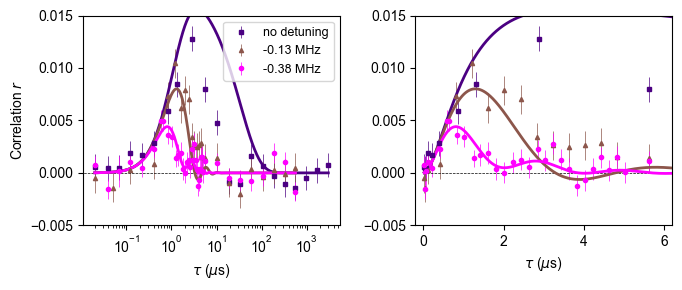

In [1726]:
fig, axs = plt.subplots(1,2,figsize=(7,3)); ifAntiCorr=1; idx=7; ifFit=0

xt0 = np.logspace(np.log10(x0[0]),np.log10(x0[-1]),10001)
xt= np.logspace(np.log10(x[0]),np.log10(x[-1]),10001)
xt2 = np.logspace(np.log10(x2[0]),np.log10(x2[-1]),10001)
yt0 = f0(xt0,A,gd, gd12); yt = f(xt,A,gd, gd12); yt2 = f2(xt2,A,gd, gd12)
# yt0 = f0(xt0,guess[0],guess[1], guess[2]); yt = f(xt,guess[0],guess[1], guess[2]); yt2 = f2(xt2,guess[0],guess[1], guess[2])
# ###############################################################################################
if True:
    axs[0].errorbar(x0,y0,err0, marker='s',linewidth=0.0, elinewidth=0.5,
                    markersize=3, label='no detuning',color="#4B0082")
    axs[0].errorbar(x,y,err, marker='^',linewidth=0.0, elinewidth=0.5,
                    markersize=3, label='-0.13 MHz',color="C5")
    axs[0].errorbar(x2,y2,err2, marker='o',linewidth=0.0, elinewidth=0.5,
                    markersize=3, label='-0.38 MHz',color="magenta")
    axs[0].hlines(y=0,xmin=0,xmax=max(x0),linestyle='--',color='k',linewidth=0.5)
    axs[0].plot(xt0, yt0, linewidth=2, markersize=3, color="#4B0082",label=None)
    axs[0].plot(xt, yt, linewidth=2, markersize=3, color='C5',label=None)
    axs[0].plot(xt2, yt2, linewidth=2, markersize=3, color='magenta',label=None)

    axs[1].errorbar(x0,y0,err0, marker='s',linewidth=0.0, elinewidth=0.5,
                    markersize=3, label='no detuning',color="#4B0082")
    axs[1].errorbar(x,y,err, marker='^',linewidth=0.0, elinewidth=0.5,
                    markersize=3, label='-0.13 MHz',color="C5")
    axs[1].errorbar(x2,y2,err2, marker='o',linewidth=0.0, elinewidth=0.5,
                    markersize=3, label='-0.38 MHz',color="magenta",capsize=0)
    axs[1].hlines(y=0,xmin=0,xmax=max(x0),linestyle='--',color='k',linewidth=0.5)
    axs[1].plot(xt0, yt0, linewidth=2, markersize=3, color="#4B0082",label=None)
    axs[1].plot(xt, yt, linewidth=2, markersize=3, color='C5',label=None)
    axs[1].plot(xt2, yt2, linewidth=2, markersize=3, color='magenta',label=None)
    

    for i in range(2):
        axs[0].set_xscale('log')
        axs[1].set_xlim((-0.2,6.2))
        axs[i].set_ylim((-0.005, 0.015))
        axs[i].set_xlabel('$\\tau$ ($\mu$s)')
        axs[0].set_ylabel('Correlation $r$')
        axs[0].legend(fontsize=9,loc='upper right')

    plt.tight_layout()

### Partially fix detuning, free d1a, d2a

In [1132]:
def f(t_eval, A, Gamma_tot_d, gamma_d_12, d1a, d2a):
    #Parameters
    # A=0.05
    delta_1z = d1a*2*pi #detuning on NV_1
    delta_2z = d2a*2*pi #detuning on NV_2
    phi = -pi/2
    amp_1 = 1.012 * np.exp(1j * phi)#using the same notations as in single_qubit simulations
    amp_2 = 1.115 * np.exp(1j * phi)#using the same notations as in single_qubit simulations
    tau_c = 0.1

    Gamma_1 = 2 * (2 * np.pi)**0.5 * tau_c * np.abs(amp_1)**2
    Gamma_2 = 2 * (2 * np.pi)**0.5 * tau_c * np.abs(amp_2)**2

    Gamma_tot_r = Gamma_1 + Gamma_2
    Gamma_tot = Gamma_tot_r + Gamma_tot_d

    Mat = np.array([[- Gamma_tot_r, 2 * np.sqrt(Gamma_1 * Gamma_2), 0, 0, 0],
                    [2 * np.sqrt(Gamma_1 * Gamma_2), - Gamma_tot,  4 * gamma_d_12, delta_1z, delta_2z],
                    [0, 4 * gamma_d_12, - Gamma_tot_d, - delta_2z, - delta_1z],
                    [0, - delta_1z, delta_2z, - (Gamma_2 + Gamma_tot_d), - 4 * gamma_d_12],
                    [0, - delta_2z, delta_1z, - 4 * gamma_d_12, - (Gamma_1 + Gamma_tot_d)]])

    eigenvalues, eigenvectors = np.linalg.eig(Mat)
    normalized_eigenvectors = eigenvectors / np.linalg.norm(eigenvectors, axis=0)
    initial_vector = np.array([1, 0, 0, 0, 0])
    coefficients = np.linalg.inv(normalized_eigenvectors).dot(initial_vector)

    analytical = coefficients[0] * np.exp(eigenvalues[0] * t_eval) * normalized_eigenvectors[0, 0] +\
        coefficients[1] * np.exp(eigenvalues[1] * t_eval) * normalized_eigenvectors[0, 1] +\
        coefficients[2] * np.exp(eigenvalues[2] * t_eval) * normalized_eigenvectors[0, 2] +\
        coefficients[3] * np.exp(eigenvalues[3] * t_eval) * normalized_eigenvectors[0, 3] +\
        coefficients[4] * np.exp(eigenvalues[4] * t_eval) * normalized_eigenvectors[0, 4] -\
        np.exp(- (Gamma_1 + Gamma_2) * t_eval)
    # print('done f')
    return A*analytical.real

def f0(t_eval, A, Gamma_tot_d, gamma_d_12):
    #Parameters
    # A=0.05
    delta_1z = 0*2*pi #detuning on NV_1
    delta_2z = 0*2*pi #detuning on NV_2
    phi = -pi/2
    amp_1 = 1.012 * np.exp(1j * phi)#using the same notations as in single_qubit simulations
    amp_2 = 1.115 * np.exp(1j * phi)#using the same notations as in single_qubit simulations
    tau_c = 0.1

    Gamma_1 = 2 * (2 * np.pi)**0.5 * tau_c * np.abs(amp_1)**2
    Gamma_2 = 2 * (2 * np.pi)**0.5 * tau_c * np.abs(amp_2)**2

    Gamma_tot_r = Gamma_1 + Gamma_2
    Gamma_tot = Gamma_tot_r + Gamma_tot_d

    Mat = np.array([[- Gamma_tot_r, 2 * np.sqrt(Gamma_1 * Gamma_2), 0, 0, 0],
                    [2 * np.sqrt(Gamma_1 * Gamma_2), - Gamma_tot,  4 * gamma_d_12, delta_1z, delta_2z],
                    [0, 4 * gamma_d_12, - Gamma_tot_d, - delta_2z, - delta_1z],
                    [0, - delta_1z, delta_2z, - (Gamma_2 + Gamma_tot_d), - 4 * gamma_d_12],
                    [0, - delta_2z, delta_1z, - 4 * gamma_d_12, - (Gamma_1 + Gamma_tot_d)]])

    eigenvalues, eigenvectors = np.linalg.eig(Mat)
    normalized_eigenvectors = eigenvectors / np.linalg.norm(eigenvectors, axis=0)
    initial_vector = np.array([1, 0, 0, 0, 0])
    coefficients = np.linalg.inv(normalized_eigenvectors).dot(initial_vector)

    analytical = coefficients[0] * np.exp(eigenvalues[0] * t_eval) * normalized_eigenvectors[0, 0] +\
        coefficients[1] * np.exp(eigenvalues[1] * t_eval) * normalized_eigenvectors[0, 1] +\
        coefficients[2] * np.exp(eigenvalues[2] * t_eval) * normalized_eigenvectors[0, 2] +\
        coefficients[3] * np.exp(eigenvalues[3] * t_eval) * normalized_eigenvectors[0, 3] +\
        coefficients[4] * np.exp(eigenvalues[4] * t_eval) * normalized_eigenvectors[0, 4] -\
        np.exp(- (Gamma_1 + Gamma_2) * t_eval)
    # print('done f0')
    return A*analytical.real

def f2(t_eval, A, Gamma_tot_d, gamma_d_12, d1a, d2a):
    #Parameters
    # A=0.04
    delta_1z = (d1a+0.25)*2*pi #detuning on NV_1
    delta_2z = d2a*2*pi #detuning on NV_2
    phi = -pi/2
    amp_1 = 1.012 * np.exp(1j * phi)#using the same notations as in single_qubit simulations
    amp_2 = 1.115 * np.exp(1j * phi)#using the same notations as in single_qubit simulations
    tau_c = 0.1

    Gamma_1 = 2 * (2 * np.pi)**0.5 * tau_c * np.abs(amp_1)**2
    Gamma_2 = 2 * (2 * np.pi)**0.5 * tau_c * np.abs(amp_2)**2

    Gamma_tot_r = Gamma_1 + Gamma_2
    Gamma_tot = Gamma_tot_r + Gamma_tot_d

    Mat = np.array([[- Gamma_tot_r, 2 * np.sqrt(Gamma_1 * Gamma_2), 0, 0, 0],
                    [2 * np.sqrt(Gamma_1 * Gamma_2), - Gamma_tot,  4 * gamma_d_12, delta_1z, delta_2z],
                    [0, 4 * gamma_d_12, - Gamma_tot_d, - delta_2z, - delta_1z],
                    [0, - delta_1z, delta_2z, - (Gamma_2 + Gamma_tot_d), - 4 * gamma_d_12],
                    [0, - delta_2z, delta_1z, - 4 * gamma_d_12, - (Gamma_1 + Gamma_tot_d)]])

    eigenvalues, eigenvectors = np.linalg.eig(Mat)
    normalized_eigenvectors = eigenvectors / np.linalg.norm(eigenvectors, axis=0)
    initial_vector = np.array([1, 0, 0, 0, 0])
    coefficients = np.linalg.inv(normalized_eigenvectors).dot(initial_vector)

    analytical = coefficients[0] * np.exp(eigenvalues[0] * t_eval) * normalized_eigenvectors[0, 0] +\
        coefficients[1] * np.exp(eigenvalues[1] * t_eval) * normalized_eigenvectors[0, 1] +\
        coefficients[2] * np.exp(eigenvalues[2] * t_eval) * normalized_eigenvectors[0, 2] +\
        coefficients[3] * np.exp(eigenvalues[3] * t_eval) * normalized_eigenvectors[0, 3] +\
        coefficients[4] * np.exp(eigenvalues[4] * t_eval) * normalized_eigenvectors[0, 4] -\
        np.exp(- (Gamma_1 + Gamma_2) * t_eval)
    # print('done f2')
    # print(analytical.real)
    return A*analytical.real

# Define objective function
def objective(params, t_eval0, t_eval, t_eval2, y0,y,y2):
    A = params['A'].value
    gd = params['Gamma_tot_d'].value
    gd12  = params['gamma_d_12'].value
    d1a  = params['d1a'].value
    d2a  = params['d2a'].value
    res0 = y0 - f0(t_eval0, A, gd, gd12)
    res  = y -  f(t_eval, A, gd, gd12, d1a, d2a)
    res2 = y2 - f2(t_eval2, A, gd, gd12, d1a, d2a)
    return np.concatenate((res0, res, res2))  # Combine residuals

# Define shared and unique parameters
if True:
    guess = np.array([0.055, 1.5, 0.35, 0.25,0])
    params = Parameters()
    params.add('A', value=guess[0], min=0.02,max=0.06)
    params.add('Gamma_tot_d', value=guess[1], min = 0,max=2)  
    params.add('gamma_d_12', value=guess[2], min = 0, max=0.5)
    params.add('d1a', value=guess[3], min = -0.5,max=0.5) 
    params.add('d2a', value=guess[4], min = -0.5,max=0.5)

In [1133]:
# Fit data
if True:
    result = minimize(objective, params, args=(t_eval0, t_eval, t_eval2,  y0,y,y2))
    A = result.params['A'].value
    gd = result.params['Gamma_tot_d'].value; gd12 = result.params['gamma_d_12'].value
    d1a = result.params['d1a'].value
    d2a = result.params['d2a'].value
    fitted_params = np.array([A,gd,gd12,d1a, d2a])

    Aerr = result.params['A'].stderr
    gderr = result.params['Gamma_tot_d'].stderr; gd12err = result.params['gamma_d_12'].stderr
    d1aerr = result.params['d1a'].stderr
    d2aerr = result.params['d2a'].stderr
    fitted_params_err = np.array([Aerr,gderr,gd12err,d1aerr, d2aerr])

    if np.any(fitted_params_err == None):
        fitted_params_err = np.array([1e6,1e6,1e6,1e6,1e6])
    
    ratios = fitted_params_err/fitted_params*100
    # sums[i,j]=np.sum(ratios)

    # Print results
    print(result.params.pretty_print())
    print(ratios)
    print(np.sum(np.abs(ratios)))


Name            Value      Min      Max   Stderr     Vary     Expr Brute_Step
A              0.0425     0.02     0.06 0.002944     True     None     None
Gamma_tot_d     0.572        0        2   0.1215     True     None     None
d1a            0.1855     -0.5      0.5  0.02035     True     None     None
d2a          -0.06337     -0.5      0.5  0.02285     True     None     None
gamma_d_12    0.08184        0      0.5  0.03287     True     None     None
None
[  6.92681867  21.23712938  40.1664852   10.96711201 -36.05495134]
115.35249660769352


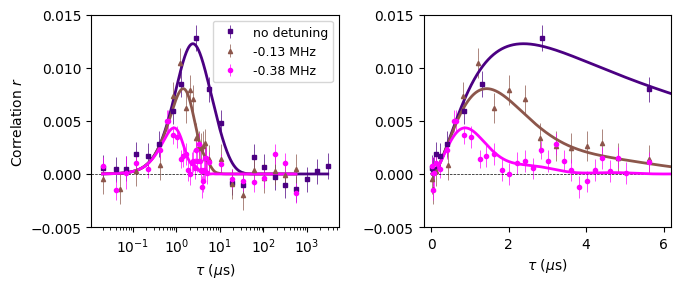

In [1134]:
fig, axs = plt.subplots(1,2,figsize=(7,3)); ifAntiCorr=1; idx=7; ifFit=0

xt0 = np.logspace(np.log10(x0[0]),np.log10(x0[-1]),10001)
xt= np.logspace(np.log10(x[0]),np.log10(x[-1]),10001)
xt2 = np.logspace(np.log10(x2[0]),np.log10(x2[-1]),10001)
yt0 = f0(xt0,A,gd, gd12); yt = f(xt,A,gd, gd12,d1a,d2a); yt2 = f2(xt2,A,gd, gd12,d1a,d2a)
# yt0 = f0(xt0,guess[0],guess[1], guess[2]); yt = f(xt,guess[0],guess[1], guess[2],guess[3], guess[4]); yt2 = f2(xt2,guess[0],guess[1], guess[2],guess[3], guess[4])
# ###############################################################################################
if True:
    axs[0].errorbar(x0,y0,err0, marker='s',linewidth=0.0, elinewidth=0.5,
                    markersize=3, label='no detuning',color="#4B0082")
    axs[0].errorbar(x,y,err, marker='^',linewidth=0.0, elinewidth=0.5,
                    markersize=3, label='-0.13 MHz',color="C5")
    axs[0].errorbar(x2,y2,err2, marker='o',linewidth=0.0, elinewidth=0.5,
                    markersize=3, label='-0.38 MHz',color="magenta")
    axs[0].hlines(y=0,xmin=0,xmax=max(x0),linestyle='--',color='k',linewidth=0.5)
    axs[0].plot(xt0, yt0, linewidth=2, markersize=3, color="#4B0082",label=None)
    axs[0].plot(xt, yt, linewidth=2, markersize=3, color='C5',label=None)
    axs[0].plot(xt2, yt2, linewidth=2, markersize=3, color='magenta',label=None)

    axs[1].errorbar(x0,y0,err0, marker='s',linewidth=0.0, elinewidth=0.5,
                    markersize=3, label='no detuning',color="#4B0082")
    axs[1].errorbar(x,y,err, marker='^',linewidth=0.0, elinewidth=0.5,
                    markersize=3, label='-0.13 MHz',color="C5")
    axs[1].errorbar(x2,y2,err2, marker='o',linewidth=0.0, elinewidth=0.5,
                    markersize=3, label='-0.38 MHz',color="magenta",capsize=0)
    axs[1].hlines(y=0,xmin=0,xmax=max(x0),linestyle='--',color='k',linewidth=0.5)
    axs[1].plot(xt0, yt0, linewidth=2, markersize=3, color="#4B0082",label=None)
    axs[1].plot(xt, yt, linewidth=2, markersize=3, color='C5',label=None)
    axs[1].plot(xt2, yt2, linewidth=2, markersize=3, color='magenta',label=None)
    

    for i in range(2):
        axs[0].set_xscale('log')
        axs[1].set_xlim((-0.2,6.2))
        axs[i].set_ylim((-0.005, 0.015))
        axs[i].set_xlabel('$\\tau$ ($\mu$s)')
        axs[0].set_ylabel('Correlation $r$')
        axs[0].legend(fontsize=9,loc='upper right')

    plt.tight_layout()

### Fix detuning, independent corr.dephasing gd12

In [1135]:
def f(t_eval, A, Gamma_tot_d, gamma_d_12b):
    #Parameters
    delta_1z = 0.25*2*pi #detuning on NV_1
    delta_2z = 0*2*pi #detuning on NV_2
    phi = -pi/2
    amp_1 = 1.012 * np.exp(1j * phi)#using the same notations as in single_qubit simulations
    amp_2 = 1.115 * np.exp(1j * phi)#using the same notations as in single_qubit simulations
    tau_c = 0.1; gamma_d_12 = gamma_d_12b

    Gamma_1 = 2 * (2 * np.pi)**0.5 * tau_c * np.abs(amp_1)**2
    Gamma_2 = 2 * (2 * np.pi)**0.5 * tau_c * np.abs(amp_2)**2

    Gamma_tot_r = Gamma_1 + Gamma_2
    Gamma_tot = Gamma_tot_r + Gamma_tot_d

    Mat = np.array([[- Gamma_tot_r, 2 * np.sqrt(Gamma_1 * Gamma_2), 0, 0, 0],
                    [2 * np.sqrt(Gamma_1 * Gamma_2), - Gamma_tot,  4 * gamma_d_12, delta_1z, delta_2z],
                    [0, 4 * gamma_d_12, - Gamma_tot_d, - delta_2z, - delta_1z],
                    [0, - delta_1z, delta_2z, - (Gamma_2 + Gamma_tot_d), - 4 * gamma_d_12],
                    [0, - delta_2z, delta_1z, - 4 * gamma_d_12, - (Gamma_1 + Gamma_tot_d)]])

    eigenvalues, eigenvectors = np.linalg.eig(Mat)
    normalized_eigenvectors = eigenvectors / np.linalg.norm(eigenvectors, axis=0)
    initial_vector = np.array([1, 0, 0, 0, 0])
    coefficients = np.linalg.inv(normalized_eigenvectors).dot(initial_vector)

    analytical = coefficients[0] * np.exp(eigenvalues[0] * t_eval) * normalized_eigenvectors[0, 0] +\
        coefficients[1] * np.exp(eigenvalues[1] * t_eval) * normalized_eigenvectors[0, 1] +\
        coefficients[2] * np.exp(eigenvalues[2] * t_eval) * normalized_eigenvectors[0, 2] +\
        coefficients[3] * np.exp(eigenvalues[3] * t_eval) * normalized_eigenvectors[0, 3] +\
        coefficients[4] * np.exp(eigenvalues[4] * t_eval) * normalized_eigenvectors[0, 4] -\
        np.exp(- (Gamma_1 + Gamma_2) * t_eval)
    # print('done f')
    return A*analytical.real

def f0(t_eval, A, Gamma_tot_d, gamma_d_12a):
    #Parameters
    # A=0.05
    delta_1z = 0*2*pi #detuning on NV_1
    delta_2z = 0*2*pi #detuning on NV_2
    phi = -pi/2
    amp_1 = 1.012 * np.exp(1j * phi)#using the same notations as in single_qubit simulations
    amp_2 = 1.115 * np.exp(1j * phi)#using the same notations as in single_qubit simulations
    tau_c = 0.1; gamma_d_12=gamma_d_12a

    Gamma_1 = 2 * (2 * np.pi)**0.5 * tau_c * np.abs(amp_1)**2
    Gamma_2 = 2 * (2 * np.pi)**0.5 * tau_c * np.abs(amp_2)**2

    Gamma_tot_r = Gamma_1 + Gamma_2
    Gamma_tot = Gamma_tot_r + Gamma_tot_d

    Mat = np.array([[- Gamma_tot_r, 2 * np.sqrt(Gamma_1 * Gamma_2), 0, 0, 0],
                    [2 * np.sqrt(Gamma_1 * Gamma_2), - Gamma_tot,  4 * gamma_d_12, delta_1z, delta_2z],
                    [0, 4 * gamma_d_12, - Gamma_tot_d, - delta_2z, - delta_1z],
                    [0, - delta_1z, delta_2z, - (Gamma_2 + Gamma_tot_d), - 4 * gamma_d_12],
                    [0, - delta_2z, delta_1z, - 4 * gamma_d_12, - (Gamma_1 + Gamma_tot_d)]])

    eigenvalues, eigenvectors = np.linalg.eig(Mat)
    normalized_eigenvectors = eigenvectors / np.linalg.norm(eigenvectors, axis=0)
    initial_vector = np.array([1, 0, 0, 0, 0])
    coefficients = np.linalg.inv(normalized_eigenvectors).dot(initial_vector)

    analytical = coefficients[0] * np.exp(eigenvalues[0] * t_eval) * normalized_eigenvectors[0, 0] +\
        coefficients[1] * np.exp(eigenvalues[1] * t_eval) * normalized_eigenvectors[0, 1] +\
        coefficients[2] * np.exp(eigenvalues[2] * t_eval) * normalized_eigenvectors[0, 2] +\
        coefficients[3] * np.exp(eigenvalues[3] * t_eval) * normalized_eigenvectors[0, 3] +\
        coefficients[4] * np.exp(eigenvalues[4] * t_eval) * normalized_eigenvectors[0, 4] -\
        np.exp(- (Gamma_1 + Gamma_2) * t_eval)
    # print('done f0')
    return A*analytical.real

def f2(t_eval, A, Gamma_tot_d, gamma_d_12c):
    #Parameters
    # A=0.04
    delta_1z = 0.5*2*pi #detuning on NV_1
    delta_2z = 0*2*pi #detuning on NV_2
    phi = -pi/2
    amp_1 = 1.012 * np.exp(1j * phi)#using the same notations as in single_qubit simulations
    amp_2 = 1.115 * np.exp(1j * phi)#using the same notations as in single_qubit simulations
    tau_c = 0.1; gamma_d_12=gamma_d_12c

    Gamma_1 = 2 * (2 * np.pi)**0.5 * tau_c * np.abs(amp_1)**2
    Gamma_2 = 2 * (2 * np.pi)**0.5 * tau_c * np.abs(amp_2)**2

    Gamma_tot_r = Gamma_1 + Gamma_2
    Gamma_tot = Gamma_tot_r + Gamma_tot_d

    Mat = np.array([[- Gamma_tot_r, 2 * np.sqrt(Gamma_1 * Gamma_2), 0, 0, 0],
                    [2 * np.sqrt(Gamma_1 * Gamma_2), - Gamma_tot,  4 * gamma_d_12, delta_1z, delta_2z],
                    [0, 4 * gamma_d_12, - Gamma_tot_d, - delta_2z, - delta_1z],
                    [0, - delta_1z, delta_2z, - (Gamma_2 + Gamma_tot_d), - 4 * gamma_d_12],
                    [0, - delta_2z, delta_1z, - 4 * gamma_d_12, - (Gamma_1 + Gamma_tot_d)]])

    eigenvalues, eigenvectors = np.linalg.eig(Mat)
    normalized_eigenvectors = eigenvectors / np.linalg.norm(eigenvectors, axis=0)
    initial_vector = np.array([1, 0, 0, 0, 0])
    coefficients = np.linalg.inv(normalized_eigenvectors).dot(initial_vector)

    analytical = coefficients[0] * np.exp(eigenvalues[0] * t_eval) * normalized_eigenvectors[0, 0] +\
        coefficients[1] * np.exp(eigenvalues[1] * t_eval) * normalized_eigenvectors[0, 1] +\
        coefficients[2] * np.exp(eigenvalues[2] * t_eval) * normalized_eigenvectors[0, 2] +\
        coefficients[3] * np.exp(eigenvalues[3] * t_eval) * normalized_eigenvectors[0, 3] +\
        coefficients[4] * np.exp(eigenvalues[4] * t_eval) * normalized_eigenvectors[0, 4] -\
        np.exp(- (Gamma_1 + Gamma_2) * t_eval)
    # print('done f2')
    # print(analytical.real)
    return A*analytical.real

# Define objective function
def objective(params, t_eval0, t_eval, t_eval2, y0,y,y2):
    A = params['A'].value
    gd = params['Gamma_tot_d'].value
    gd12a  = params['gamma_d_12a'].value
    gd12b  = params['gamma_d_12b'].value
    gd12c  = params['gamma_d_12c'].value

    params['gamma_d_12a'].max = gd*0.25
    params['gamma_d_12b'].max = gd*0.25
    params['gamma_d_12c'].max = gd*0.281  # Ensuring b is at least a

    res0 = y0 - f0(t_eval0, A, gd, gd12a)
    res  = y -  f(t_eval, A, gd, gd12b)
    res2 = y2 - f2(t_eval2, A, gd, gd12c)
    return np.concatenate((res0, res, res2))  # Combine residuals


In [1136]:
M=21; N=13; sums = np.zeros((M,N))
a = np.linspace(0,0.2,M); b = np.linspace(0.148,0.16,N)

for i, imin in enumerate(a):
    for j, imax in enumerate(b):
        # Define shared and unique parameters
        if True:
            guess = np.array([0.055, 1.85, imax, 0.34, 0.15])
            params = Parameters()
            params.add('A', value=guess[0], min=0.03,max=0.07)
            params.add('Gamma_tot_d', value=guess[1], min = 0, max=2)  
            params.add('gamma_d_12a', value=guess[2], min = 0.01)#, max=0.42)
            params.add('gamma_d_12b', value=guess[3], min = imin)#, max=imax) 
            params.add('gamma_d_12c', value=guess[4], min = 0.01)#, max=0.42)

        # Fit data
        if True:
            result = minimize(objective, params, args=(t_eval0, t_eval, t_eval2,  y0,y,y2))
            A = result.params['A'].value
            gd = result.params['Gamma_tot_d'].value; gd12a = result.params['gamma_d_12a'].value
            gd12b = result.params['gamma_d_12b'].value; gd12c = result.params['gamma_d_12c'].value
            fitted_params = np.array([A,gd,gd12a,gd12b, gd12c])

            Aerr = result.params['A'].stderr
            gderr = result.params['Gamma_tot_d'].stderr; gd12aerr = result.params['gamma_d_12a'].stderr
            gd12berr = result.params['gamma_d_12b'].stderr; gd12cerr = result.params['gamma_d_12c'].stderr
            fitted_params_err = np.array([Aerr,gderr,gd12aerr,gd12berr, gd12cerr])

            if np.any(fitted_params_err == None):
                fitted_params_err = np.array([1e6,1e6,1e6,1e6,1e6])
                
            if np.isnan(fitted_params_err).any():
                fitted_params_err = np.array([1e6,1e6,1e6,1e6,1e6])
            
            ratios = fitted_params_err/fitted_params*100
            sums[i,j]=np.sum(ratios)

            # # Print results
            # print(result.params.pretty_print())
            # print(ratios)
            # print(np.sum(ratios))

min_index = np.unravel_index(np.argmin(sums), sums.shape)
iMin = a[min_index[0]]; iMax = b[min_index[1]]
print(iMin); print(iMax)

# Fit data
if True:
    guess = np.array([0.055, 1.85, iMax, 0.34, 0.15])
    params = Parameters()
    params.add('A', value=guess[0], min=0.03,max=0.07)
    params.add('Gamma_tot_d', value=guess[1], min = 0, max=2)  
    params.add('gamma_d_12a', value=guess[2], min = 0.01)#, max=0.42)
    params.add('gamma_d_12b', value=guess[3], min = iMin)#, max=iMax) 
    params.add('gamma_d_12c', value=guess[4], min = 0.01)#, max=0.42)
    
    result = minimize(objective, params, args=(t_eval0, t_eval, t_eval2,  y0,y,y2))
    A = result.params['A'].value
    gd = result.params['Gamma_tot_d'].value; gd12a = result.params['gamma_d_12a'].value
    gd12b = result.params['gamma_d_12b'].value; gd12c = result.params['gamma_d_12c'].value
    fitted_params = np.array([A,gd,gd12a,gd12b, gd12c])

    Aerr = result.params['A'].stderr
    gderr = result.params['Gamma_tot_d'].stderr; gd12aerr = result.params['gamma_d_12a'].stderr
    gd12berr = result.params['gamma_d_12b'].stderr; gd12cerr = result.params['gamma_d_12c'].stderr
    fitted_params_err = np.array([Aerr,gderr,gd12aerr,gd12berr, gd12cerr])

    if np.any(fitted_params_err == None):
        fitted_params_err = np.array([1e6,1e6,1e6,1e6,1e6])
    
    ratios = fitted_params_err/fitted_params*100
    sums[i,j]=np.sum(ratios)

    # Print results
    print(result.params.pretty_print())
    print(ratios)
    print(np.sum(ratios))

0.15
0.149
Name            Value      Min      Max   Stderr     Vary     Expr Brute_Step
A             0.05558     0.03     0.07 0.002793     True     None     None
Gamma_tot_d     1.498        0        2   0.2813     True     None     None
gamma_d_12a    0.3008     0.01   0.3744  0.01387     True     None     None
gamma_d_12b    0.1507     0.15   0.3744 0.005113     True     None     None
gamma_d_12c    0.4063     0.01   0.4208  0.05103     True     None     None
None
[ 5.0250468  18.78278514  4.61267977  3.39212723 12.5607587 ]
44.37339763667225


In [1139]:
guess = np.array([0.055, 1.85, 0.149, 0.34, 0.15])
params = Parameters()
params.add('A', value=guess[0], min=0.03,max=0.07)
params.add('Gamma_tot_d', value=guess[1], min = 0, max=2)  
params.add('gamma_d_12a', value=guess[2], min = 0.01)#, max=0.42)
params.add('gamma_d_12b', value=guess[3], min = 0.15)#, max=0.54) 
params.add('gamma_d_12c', value=guess[4], min = 0.01)#, max=0.42)

# Fit data
if True:    
    result = minimize(objective, params, args=(t_eval0, t_eval, t_eval2,  y0,y,y2))
    A = result.params['A'].value
    gd = result.params['Gamma_tot_d'].value; gd12a = result.params['gamma_d_12a'].value
    gd12b = result.params['gamma_d_12b'].value; gd12c = result.params['gamma_d_12c'].value
    fitted_params = np.array([A,gd,gd12a,gd12b, gd12c])

    Aerr = result.params['A'].stderr
    gderr = result.params['Gamma_tot_d'].stderr; gd12aerr = result.params['gamma_d_12a'].stderr
    gd12berr = result.params['gamma_d_12b'].stderr; gd12cerr = result.params['gamma_d_12c'].stderr
    fitted_params_err = np.array([Aerr,gderr,gd12aerr,gd12berr, gd12cerr])

    if np.any(fitted_params_err == None):
        fitted_params_err = np.array([1e6,1e6,1e6,1e6,1e6])
    
    ratios = fitted_params_err/fitted_params*100
    # sums[i,j]=np.sum(ratios)

    # Print results
    print(result.params.pretty_print())
    print(ratios)
    print(np.sum(ratios))


Name            Value      Min      Max   Stderr     Vary     Expr Brute_Step
A             0.05558     0.03     0.07 0.002793     True     None     None
Gamma_tot_d     1.498        0        2   0.2813     True     None     None
gamma_d_12a    0.3008     0.01   0.3744  0.01387     True     None     None
gamma_d_12b    0.1507     0.15   0.3744 0.005113     True     None     None
gamma_d_12c    0.4063     0.01   0.4208  0.05103     True     None     None
None
[ 5.0250468  18.78278514  4.61267977  3.39212723 12.5607587 ]
44.37339763667225


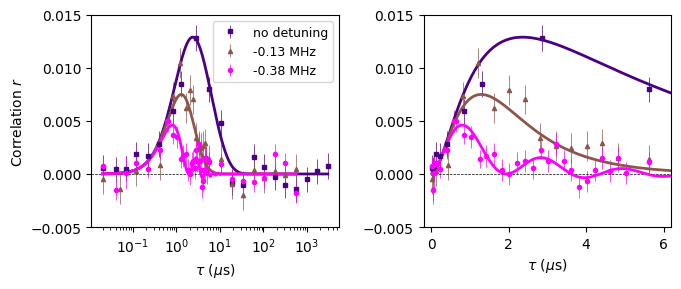

In [1140]:
fig, axs = plt.subplots(1,2,figsize=(7,3)); ifAntiCorr=1; idx=7; ifFit=0

xt0 = np.logspace(np.log10(x0[0]),np.log10(x0[-1]),10001)
xt= np.logspace(np.log10(x[0]),np.log10(x[-1]),10001)
xt2 = np.logspace(np.log10(x2[0]),np.log10(x2[-1]),10001)
yt0 = f0(xt0,A,gd, gd12a); yt = f(xt,A,gd, gd12b); yt2 = f2(xt2,A,gd, gd12c)
# yt0 = f0(xt0, guess[0],guess[1], guess[2]); yt = f(xt,guess[0],guess[1], guess[3]); yt2 = f2(xt2,guess[0],guess[1], guess[4])
# ###############################################################################################
if True:
    axs[0].errorbar(x0,y0,err0, marker='s',linewidth=0.0, elinewidth=0.5,
                    markersize=3, label='no detuning',color="#4B0082")
    axs[0].errorbar(x,y,err, marker='^',linewidth=0.0, elinewidth=0.5,
                    markersize=3, label='-0.13 MHz',color="C5")
    axs[0].errorbar(x2,y2,err2, marker='o',linewidth=0.0, elinewidth=0.5,
                    markersize=3, label='-0.38 MHz',color="magenta")
    axs[0].hlines(y=0,xmin=0,xmax=max(x0),linestyle='--',color='k',linewidth=0.5)
    axs[0].plot(xt0, yt0, linewidth=2, markersize=3, color="#4B0082",label=None)
    axs[0].plot(xt, yt, linewidth=2, markersize=3, color='C5',label=None)
    axs[0].plot(xt2, yt2, linewidth=2, markersize=3, color='magenta',label=None)

    axs[1].errorbar(x0,y0,err0, marker='s',linewidth=0.0, elinewidth=0.5,
                    markersize=3, label='no detuning',color="#4B0082")
    axs[1].errorbar(x,y,err, marker='^',linewidth=0.0, elinewidth=0.5,
                    markersize=3, label='-0.13 MHz',color="C5")
    axs[1].errorbar(x2,y2,err2, marker='o',linewidth=0.0, elinewidth=0.5,
                    markersize=3, label='-0.38 MHz',color="magenta",capsize=0)
    axs[1].hlines(y=0,xmin=0,xmax=max(x0),linestyle='--',color='k',linewidth=0.5)
    axs[1].plot(xt0, yt0, linewidth=2, markersize=3, color="#4B0082",label=None)
    axs[1].plot(xt, yt, linewidth=2, markersize=3, color='C5',label=None)
    axs[1].plot(xt2, yt2, linewidth=2, markersize=3, color='magenta',label=None)
    

    for i in range(2):
        axs[0].set_xscale('log')
        axs[1].set_xlim((-0.2,6.2))
        axs[i].set_ylim((-0.005, 0.015))
        axs[i].set_xlabel('$\\tau$ ($\mu$s)')
        axs[0].set_ylabel('Correlation $r$')
        axs[0].legend(fontsize=9,loc='upper right')

    plt.tight_layout()

### Fix detuning, independent gd11

In [575]:
phi = -pi/2
amp_1 = 1.010 * np.exp(1j * phi)#using the same notations as in single_qubit simulations
amp_2 = 1.062 * np.exp(1j * phi)#using the same notations as in single_qubit simulations
tau_c = 0.1

Gamma_1 = 2 * (2 * np.pi)**0.5 * tau_c * np.abs(amp_1)**2
Gamma_2 = 2 * (2 * np.pi)**0.5 * tau_c * np.abs(amp_2)**2
print(Gamma_1)
print(Gamma_2)
print((np.sqrt(Gamma_1)-np.sqrt(Gamma_2))**2*1e3)

0.5114023005902167
0.5654171319545852
1.3555845709204413


In [555]:
def f(t_eval, A, Gamma_tot_db, gamma_d_12):
    #Parameters
    delta_1z = 0.25*2*pi #detuning on NV_1
    delta_2z = 0*2*pi #detuning on NV_2
    phi = -pi/2
    amp_1 = 1.010 * np.exp(1j * phi)#using the same notations as in single_qubit simulations
    amp_2 = 1.062 * np.exp(1j * phi)#using the same notations as in single_qubit simulations
    tau_c = 0.1; Gamma_tot_d = Gamma_tot_db

    Gamma_1 = 2 * (2 * np.pi)**0.5 * tau_c * np.abs(amp_1)**2
    Gamma_2 = 2 * (2 * np.pi)**0.5 * tau_c * np.abs(amp_2)**2

    Gamma_tot_r = Gamma_1 + Gamma_2
    Gamma_tot = Gamma_tot_r + Gamma_tot_d

    Mat = np.array([[- Gamma_tot_r, 2 * np.sqrt(Gamma_1 * Gamma_2), 0, 0, 0],
                    [2 * np.sqrt(Gamma_1 * Gamma_2), - Gamma_tot,  4 * gamma_d_12, delta_1z, delta_2z],
                    [0, 4 * gamma_d_12, - Gamma_tot_d, - delta_2z, - delta_1z],
                    [0, - delta_1z, delta_2z, - (Gamma_2 + Gamma_tot_d), - 4 * gamma_d_12],
                    [0, - delta_2z, delta_1z, - 4 * gamma_d_12, - (Gamma_1 + Gamma_tot_d)]])

    eigenvalues, eigenvectors = np.linalg.eig(Mat)
    normalized_eigenvectors = eigenvectors / np.linalg.norm(eigenvectors, axis=0)
    initial_vector = np.array([1, 0, 0, 0, 0])
    coefficients = np.linalg.inv(normalized_eigenvectors).dot(initial_vector)

    analytical = coefficients[0] * np.exp(eigenvalues[0] * t_eval) * normalized_eigenvectors[0, 0] +\
        coefficients[1] * np.exp(eigenvalues[1] * t_eval) * normalized_eigenvectors[0, 1] +\
        coefficients[2] * np.exp(eigenvalues[2] * t_eval) * normalized_eigenvectors[0, 2] +\
        coefficients[3] * np.exp(eigenvalues[3] * t_eval) * normalized_eigenvectors[0, 3] +\
        coefficients[4] * np.exp(eigenvalues[4] * t_eval) * normalized_eigenvectors[0, 4] -\
        np.exp(- (Gamma_1 + Gamma_2) * t_eval)
    # print('done f')
    return A*analytical.real

def f0(t_eval, A, Gamma_tot_da, gamma_d_12):
    #Parameters
    # A=0.05
    delta_1z = 0*2*pi #detuning on NV_1
    delta_2z = 0*2*pi #detuning on NV_2
    phi = -pi/2
    amp_1 = 1.010 * np.exp(1j * phi)#using the same notations as in single_qubit simulations
    amp_2 = 1.062 * np.exp(1j * phi)#using the same notations as in single_qubit simulations
    tau_c = 0.1; Gamma_tot_d=Gamma_tot_da

    Gamma_1 = 2 * (2 * np.pi)**0.5 * tau_c * np.abs(amp_1)**2
    Gamma_2 = 2 * (2 * np.pi)**0.5 * tau_c * np.abs(amp_2)**2
    # print(Gamma_1); print(Gamma_2)
    Gamma_tot_r = Gamma_1 + Gamma_2
    Gamma_tot = Gamma_tot_r + Gamma_tot_d

    Mat = np.array([[- Gamma_tot_r, 2 * np.sqrt(Gamma_1 * Gamma_2), 0, 0, 0],
                    [2 * np.sqrt(Gamma_1 * Gamma_2), - Gamma_tot,  4 * gamma_d_12, delta_1z, delta_2z],
                    [0, 4 * gamma_d_12, - Gamma_tot_d, - delta_2z, - delta_1z],
                    [0, - delta_1z, delta_2z, - (Gamma_2 + Gamma_tot_d), - 4 * gamma_d_12],
                    [0, - delta_2z, delta_1z, - 4 * gamma_d_12, - (Gamma_1 + Gamma_tot_d)]])

    eigenvalues, eigenvectors = np.linalg.eig(Mat)
    normalized_eigenvectors = eigenvectors / np.linalg.norm(eigenvectors, axis=0)
    initial_vector = np.array([1, 0, 0, 0, 0])
    coefficients = np.linalg.inv(normalized_eigenvectors).dot(initial_vector)

    analytical = coefficients[0] * np.exp(eigenvalues[0] * t_eval) * normalized_eigenvectors[0, 0] +\
        coefficients[1] * np.exp(eigenvalues[1] * t_eval) * normalized_eigenvectors[0, 1] +\
        coefficients[2] * np.exp(eigenvalues[2] * t_eval) * normalized_eigenvectors[0, 2] +\
        coefficients[3] * np.exp(eigenvalues[3] * t_eval) * normalized_eigenvectors[0, 3] +\
        coefficients[4] * np.exp(eigenvalues[4] * t_eval) * normalized_eigenvectors[0, 4] -\
        np.exp(- (Gamma_1 + Gamma_2) * t_eval)
    # print('done f0')
    return A*analytical.real

def f2(t_eval, A, Gamma_tot_dc, gamma_d_12):
    #Parameters
    # A=0.04
    delta_1z = 0.5*2*pi #detuning on NV_1
    delta_2z = 0*2*pi #detuning on NV_2
    phi = -pi/2
    amp_1 = 1.010 * np.exp(1j * phi)#using the same notations as in single_qubit simulations
    amp_2 = 1.162 * np.exp(1j * phi)#using the same notations as in single_qubit simulations
    tau_c = 0.1; Gamma_tot_d=Gamma_tot_dc

    Gamma_1 = 2 * (2 * np.pi)**0.5 * tau_c * np.abs(amp_1)**2
    Gamma_2 = 2 * (2 * np.pi)**0.5 * tau_c * np.abs(amp_2)**2

    Gamma_tot_r = Gamma_1 + Gamma_2
    Gamma_tot = Gamma_tot_r + Gamma_tot_d

    Mat = np.array([[- Gamma_tot_r, 2 * np.sqrt(Gamma_1 * Gamma_2), 0, 0, 0],
                    [2 * np.sqrt(Gamma_1 * Gamma_2), - Gamma_tot,  4 * gamma_d_12, delta_1z, delta_2z],
                    [0, 4 * gamma_d_12, - Gamma_tot_d, - delta_2z, - delta_1z],
                    [0, - delta_1z, delta_2z, - (Gamma_2 + Gamma_tot_d), - 4 * gamma_d_12],
                    [0, - delta_2z, delta_1z, - 4 * gamma_d_12, - (Gamma_1 + Gamma_tot_d)]])

    eigenvalues, eigenvectors = np.linalg.eig(Mat)
    normalized_eigenvectors = eigenvectors / np.linalg.norm(eigenvectors, axis=0)
    initial_vector = np.array([1, 0, 0, 0, 0])
    coefficients = np.linalg.inv(normalized_eigenvectors).dot(initial_vector)

    analytical = coefficients[0] * np.exp(eigenvalues[0] * t_eval) * normalized_eigenvectors[0, 0] +\
        coefficients[1] * np.exp(eigenvalues[1] * t_eval) * normalized_eigenvectors[0, 1] +\
        coefficients[2] * np.exp(eigenvalues[2] * t_eval) * normalized_eigenvectors[0, 2] +\
        coefficients[3] * np.exp(eigenvalues[3] * t_eval) * normalized_eigenvectors[0, 3] +\
        coefficients[4] * np.exp(eigenvalues[4] * t_eval) * normalized_eigenvectors[0, 4] -\
        np.exp(- (Gamma_1 + Gamma_2) * t_eval)
    # print('done f2')
    # print(analytical.real)
    return A*analytical.real

# Define objective function
def objective(params, t_eval0, t_eval, t_eval2, y0,y,y2):
    A = params['A'].value
    gd12 = params['gamma_d_12'].value
    gda  = params['Gamma_tot_da'].value
    gdb  = params['Gamma_tot_db'].value
    gdc  = params['Gamma_tot_dc'].value

    # params['gamma_d_12'].max = np.min((gda*0.25, gdb*0.25, gdc*0.281))  # Ensuring b is at least a

    res0 = y0 - f0(t_eval0, A, gda, gd12)
    res  = y -  f(t_eval, A, gdb, gd12)
    res2 = y2 - f2(t_eval2, A, gdc, gd12)
    return np.concatenate((res0, res, res2))  # Combine residuals


In [8]:
# M=11; N=12; sums = np.zeros((M,N))
# a = np.linspace(0.2,0.4,M); b = np.linspace(1.99,2.10,N)

# for i, imin in enumerate(a):
#     # print(imin)
#     for j, imax in enumerate(b):
#         if True:
#             guess = np.array([0.055, 0.4, 1.85,1.85,1.84])
#             params = Parameters()
#             params.add('A', value=guess[0], min=0.03,max=0.07)
#             params.add('gamma_d_12', value=guess[1], min = 0.09, max=imax)  
#             params.add('Gamma_tot_da', value=guess[2], min = imin, max=imax)
#             params.add('Gamma_tot_db', value=guess[3], min = imin, max=imax) 
#             params.add('Gamma_tot_dc', value=guess[4], min = imin, max=imax)
        
#         # Fit data
#         if True:    
#             result = minimize(objective, params, args=(t_eval0, t_eval, t_eval2,  y0,y,y2))
#             A = result.params['A'].value
#             gd12 = result.params['gamma_d_12'].value; gda = result.params['Gamma_tot_da'].value
#             gdb = result.params['Gamma_tot_db'].value; gdc = result.params['Gamma_tot_dc'].value
#             fitted_params = np.array([A,gd12,gda,gdb, gdc])

#             Aerr = result.params['A'].stderr
#             gd12err = result.params['gamma_d_12'].stderr; gdaerr = result.params['Gamma_tot_da'].stderr
#             gdberr = result.params['Gamma_tot_db'].stderr; gdcerr = result.params['Gamma_tot_dc'].stderr
#             fitted_params_err = np.array([Aerr,gd12err,gdaerr,gdberr, gdcerr])

#             if np.any(fitted_params_err == None):
#                 fitted_params_err = np.array([1e6,1e6,1e6,1e6,1e6])
            
#             ratios = fitted_params_err/fitted_params*100
#             sums[i,j]=np.sum(ratios)

# min_index = np.unravel_index(np.argmin(sums), sums.shape)
# iMin = a[min_index[0]]; iMax = b[min_index[1]]
# print(iMin); print(iMax)

# # Fit data
# if True:    
#     params = Parameters()
#     params.add('A', value=guess[0], min=0.03,max=0.07)
#     params.add('gamma_d_12', value=guess[1], min = 0.09, max=iMax)  
#     params.add('Gamma_tot_da', value=guess[2], min = iMin, max=iMax)
#     params.add('Gamma_tot_db', value=guess[3], min = iMin, max=iMax) 
#     params.add('Gamma_tot_dc', value=guess[4], min = iMin, max=iMax)
#     if True:
#         result = minimize(objective, params, args=(t_eval0, t_eval, t_eval2,  y0,y,y2))
#         A = result.params['A'].value
#         gd12 = result.params['gamma_d_12'].value; gda = result.params['Gamma_tot_da'].value
#         gdb = result.params['Gamma_tot_db'].value; gdc = result.params['Gamma_tot_dc'].value
#         fitted_params = np.array([A,gd12,gda,gdb, gdc])

#         Aerr = result.params['A'].stderr
#         gd12err = result.params['gamma_d_12'].stderr; gdaerr = result.params['Gamma_tot_da'].stderr
#         gdberr = result.params['Gamma_tot_db'].stderr; gdcerr = result.params['Gamma_tot_dc'].stderr
#         fitted_params_err = np.array([Aerr,gd12err,gdaerr,gdberr, gdcerr])

#         if np.any(fitted_params_err == None):
#             fitted_params_err = np.array([1e6,1e6,1e6,1e6,1e6])
        
#         ratios = fitted_params_err/fitted_params*100
#         # sums[i,j]=np.sum(ratios)

#         # Print results
#         print(result.params.pretty_print())
#         print(ratios)
#         print(np.sum(ratios))

In [9]:
M=5; N=5; sums = np.zeros((M,N))
a = np.linspace(0.29,0.33,M); b = np.linspace(0.83,0.87,N)

for i, imin in enumerate(a):
    imin = np.round(imin,2)
    print(imin)
    for j, imax in enumerate(b):
        imax = np.round(imax,2)
        if True:
            guess = np.array([0.055, 0.3161, 1.4, 1.1, 0.8262])
            params = Parameters()
            params.add('A', value=guess[0], min=0.053,max=0.057)
            params.add('gamma_d_12', value=guess[1], min = imin, max=0.4)  
            params.add('Gamma_tot_da', value=guess[2], min = 0.68, max=1.5)
            params.add('Gamma_tot_db', value=guess[3], min = 0.28, max=1.85) 
            params.add('Gamma_tot_dc', value=guess[4], min = 0.8, max=imax)
        
        # Fit data
        if True:    
            result = minimize(objective, params, args=(t_eval0, t_eval, t_eval2,  y0,y,y2))
            A = result.params['A'].value
            gd12 = result.params['gamma_d_12'].value; gda = result.params['Gamma_tot_da'].value
            gdb = result.params['Gamma_tot_db'].value; gdc = result.params['Gamma_tot_dc'].value
            fitted_params = np.array([A,gd12,gda,gdb, gdc])

            Aerr = result.params['A'].stderr
            gd12err = result.params['gamma_d_12'].stderr; gdaerr = result.params['Gamma_tot_da'].stderr
            gdberr = result.params['Gamma_tot_db'].stderr; gdcerr = result.params['Gamma_tot_dc'].stderr
            fitted_params_err = np.array([Aerr,gd12err,gdaerr,gdberr, gdcerr])

            if np.any(fitted_params_err == None):
                fitted_params_err = np.array([1e6,1e6,1e6,1e6,1e6])
            
            ratios = fitted_params_err/fitted_params*100
            sums[i,j]=np.sum(ratios)

min_index = np.unravel_index(np.argmin(sums), sums.shape)
iMin = a[min_index[0]]; iMax = b[min_index[1]]
print(iMin); print(iMax)

# Fit data
if True:    
    params = Parameters()
    params.add('A', value=guess[0], min=0.053,max=0.057)
    params.add('gamma_d_12', value=guess[1], min = iMin, max=0.4)  
    params.add('Gamma_tot_da', value=guess[2], min = 0.68, max=1.5)
    params.add('Gamma_tot_db', value=guess[3], min = 0.28, max=1.85) 
    params.add('Gamma_tot_dc', value=guess[4], min = 0.8, max=iMax)
    if True:
        result = minimize(objective, params, args=(t_eval0, t_eval, t_eval2,  y0,y,y2))
        A = result.params['A'].value
        gd12 = result.params['gamma_d_12'].value; gda = result.params['Gamma_tot_da'].value
        gdb = result.params['Gamma_tot_db'].value; gdc = result.params['Gamma_tot_dc'].value
        fitted_params = np.array([A,gd12,gda,gdb, gdc])

        Aerr = result.params['A'].stderr
        gd12err = result.params['gamma_d_12'].stderr; gdaerr = result.params['Gamma_tot_da'].stderr
        gdberr = result.params['Gamma_tot_db'].stderr; gdcerr = result.params['Gamma_tot_dc'].stderr
        fitted_params_err = np.array([Aerr,gd12err,gdaerr,gdberr, gdcerr])

        if np.any(fitted_params_err == None):
            fitted_params_err = np.array([1e6,1e6,1e6,1e6,1e6])
        
        ratios = fitted_params_err/fitted_params*100
        # sums[i,j]=np.sum(ratios)

        # Print results
        print(result.params.pretty_print())
        print(ratios)
        print(np.sum(ratios))

0.29
0.3
0.31
0.32
0.33
0.29
0.86
Name             Value      Min      Max   Stderr     Vary     Expr Brute_Step
A              0.05691    0.053    0.057 0.004672     True     None     None
Gamma_tot_da     1.484     0.68      1.5   0.5279     True     None     None
Gamma_tot_db     1.778     0.28     1.85   0.6458     True     None     None
Gamma_tot_dc      0.86      0.8     0.86   0.4756     True     None     None
gamma_d_12        0.29     0.29      0.4   0.1254     True     None     None
None
[ 8.20987506 43.24231876 35.5678534  36.31750753 55.30529379]
178.64284853294924


In [319]:
# guess = np.array([0.055, 0.3161, 1.299, 1.1, 0.8262])
guess = np.array([0.05691, 0.29, 1.484, 1.778, 0.86])
guess = np.array([0.055, 0.3161, 1.4, 1.1, 0.8262])
params = Parameters()
params.add('A', value=guess[0], min=0.053,max=0.057)
params.add('gamma_d_12', value=guess[1], min = 0.29, max=0.4)  
params.add('Gamma_tot_da', value=guess[2], min = 0.68, max=1.5)
params.add('Gamma_tot_db', value=guess[3], min = 0.28, max=1.85) 
params.add('Gamma_tot_dc', value=guess[4], min = 0.8, max=0.86)

# Fit data
if True:    
    result = minimize(objective, params, args=(t_eval0, t_eval, t_eval2,  y0,y,y2))
    A = result.params['A'].value
    gd12 = result.params['gamma_d_12'].value; gda = result.params['Gamma_tot_da'].value
    gdb = result.params['Gamma_tot_db'].value; gdc = result.params['Gamma_tot_dc'].value
    fitted_params = np.array([A,gd12,gda,gdb, gdc])

    Aerr = result.params['A'].stderr
    gd12err = result.params['gamma_d_12'].stderr; gdaerr = result.params['Gamma_tot_da'].stderr
    gdberr = result.params['Gamma_tot_db'].stderr; gdcerr = result.params['Gamma_tot_dc'].stderr
    fitted_params_err = np.array([Aerr,gd12err,gdaerr,gdberr, gdcerr])

    if np.any(fitted_params_err == None):
        fitted_params_err = np.array([1e6,1e6,1e6,1e6,1e6])
    
    ratios = fitted_params_err/fitted_params*100
    # sums[i,j]=np.sum(ratios)

    # Print results
    print(result.params.pretty_print())
    print(ratios)
    print(np.sum(ratios))


Name             Value      Min      Max   Stderr     Vary     Expr Brute_Step
A              0.05691    0.053    0.057 0.004672     True     None     None
Gamma_tot_da     1.484     0.68      1.5   0.5279     True     None     None
Gamma_tot_db     1.778     0.28     1.85   0.6458     True     None     None
Gamma_tot_dc      0.86      0.8     0.86   0.4756     True     None     None
gamma_d_12        0.29     0.29      0.4   0.1254     True     None     None
None
[ 8.20987506 43.24231876 35.5678534  36.31750753 55.30529379]
178.64284853294924


In [320]:
paramsFitted = Parameters()
paramsFitted.add('A',     value=result.params['A'].value,              min = 0.03, max=0.07 )
paramsFitted.add('gd12',  value=result.params['gamma_d_12'].value,     min = 0.09, max=0.59)  
paramsFitted.add('gd11a', value=result.params['Gamma_tot_da'].value/4, min = 0.28/4, max=1.99/4)
paramsFitted.add('gd11b', value=result.params['Gamma_tot_db'].value/4, min = 0.28/4, max=1.99/4) 
paramsFitted.add('gd11c', value=result.params['Gamma_tot_dc'].value/4, min = 0.28/4, max=1.99/4)
paramsFitted['A'].relerr = ratios[0]
paramsFitted['gd12'].relerr = ratios[1]
paramsFitted['gd11a'].relerr = ratios[2]; paramsFitted['gd11b'].relerr = ratios[3]; paramsFitted['gd11c'].relerr = ratios[4]
paramsFitted.pretty_print()
sorted_ratios=[]
for var in sorted(paramsFitted):
    sorted_ratios.append(np.round(paramsFitted[var].relerr,1))
print('Uncertainty in %: ' + str(sorted_ratios))

Name      Value      Min      Max   Stderr     Vary     Expr Brute_Step
A       0.05691     0.03     0.07     None     True     None     None
gd11a     0.371     0.07   0.4975     None     True     None     None
gd11b    0.4445     0.07   0.4975     None     True     None     None
gd11c     0.215     0.07   0.4975     None     True     None     None
gd12       0.29     0.09     0.59     None     True     None     None
Uncertainty in %: [8.2, 35.6, 36.3, 55.3, 43.2]


In [113]:
print(1e3*(gda*0.250229-gda/4))
print(1e3*(gdb*0.31195-gdb/4))
print(1e3*(gdc*0.4015-gdc/4))
print('#####################################')
print(1e3*(gda*0.250229))
print(1e3*(gdb*0.31195))
print(1e3*(gdc*0.4015))

0.3398637862845888
110.15185652538412
130.2899999024939
#####################################
371.3701981581317
554.6710515430764
345.2899997415927


In [317]:
gd12*(1-2.2215*0.25)*1e3

128.94125000111254

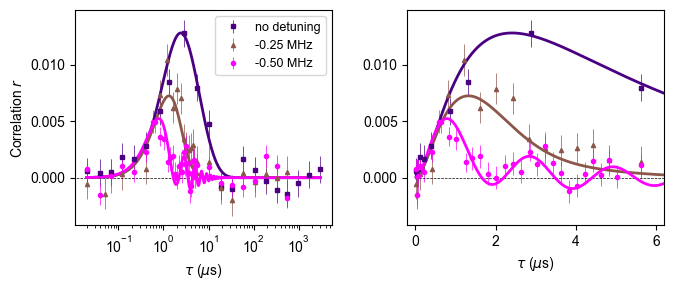

In [558]:
fig, axs = plt.subplots(1,2,figsize=(7,3)); ifAntiCorr=1; idx=7; ifFit=0

xt0 = np.logspace(np.log10(x0[0]),np.log10(x0[-1]),10001)
xt= np.logspace(np.log10(x[0]),np.log10(x0[-1]),10001)
xt2 = np.logspace(np.log10(x2[0]),np.log10(x0[-1]),10001)
yt0 = f0(xt0,A,gda,gd12); yt = f(xt,A,gdb,gd12); yt2 = f2(xt2,A,gdc,gd12)
# yt0 = f0(xt0, guess[0],guess[1], guess[2]); yt = f(xt,guess[0],guess[1], guess[3]); yt2 = f2(xt2,guess[0],guess[1], guess[4])
# ###############################################################################################
if True:
    axs[0].errorbar(x0,y0,err0, marker='s',linewidth=0.0, elinewidth=0.5,
                    markersize=3, label='no detuning',color="#4B0082")
    axs[0].errorbar(x,y,err, marker='^',linewidth=0.0, elinewidth=0.5,
                    markersize=3, label='-0.25 MHz',color="C5")
    axs[0].errorbar(x2,y2,err2, marker='o',linewidth=0.0, elinewidth=0.5,
                    markersize=3, label='-0.50 MHz',color="magenta")
    axs[0].hlines(y=0,xmin=0,xmax=max(x0),linestyle='--',color='k',linewidth=0.5)
    axs[0].plot(xt0, yt0, linewidth=2, markersize=3, color="#4B0082",label=None)
    axs[0].plot(xt, yt, linewidth=2, markersize=3, color='C5',label=None)
    axs[0].plot(xt2, yt2, linewidth=2, markersize=3, color='magenta',label=None)

    axs[1].errorbar(x0,y0,err0, marker='s',linewidth=0.0, elinewidth=0.5,
                    markersize=3, label='no detuning',color="#4B0082")
    axs[1].errorbar(x,y,err, marker='^',linewidth=0.0, elinewidth=0.5,
                    markersize=3, label='-0.25 MHz',color="C5")
    axs[1].errorbar(x2,y2,err2, marker='o',linewidth=0.0, elinewidth=0.5,
                    markersize=3, label='-0.50 MHz',color="magenta",capsize=0)
    axs[1].hlines(y=0,xmin=0,xmax=max(x0),linestyle='--',color='k',linewidth=0.5)
    axs[1].plot(xt0, yt0, linewidth=2, markersize=3, color="#4B0082",label=None)
    axs[1].plot(xt, yt, linewidth=2, markersize=3, color='C5',label=None)
    axs[1].plot(xt2, yt2, linewidth=2, markersize=3, color='magenta',label=None)
    

    for i in range(2):
        axs[0].set_xscale('log')
        axs[1].set_xlim((-0.2,6.2))
        # axs[i].set_ylim((-0.005, 0.015))
        axs[i].set_xlabel('$\\tau$ ($\mu$s)')
        axs[0].set_ylabel('Correlation $r$')
        axs[0].legend(fontsize=9,loc='upper right')

    plt.tight_layout()

[ 1.00034872 -0.02038892]
[ 0.99554396 -0.0953931 ]
[ 0.98307636 -0.10222851]
[ 0.95853068 -0.11416714]
[ 0.95196893 -0.11568174]


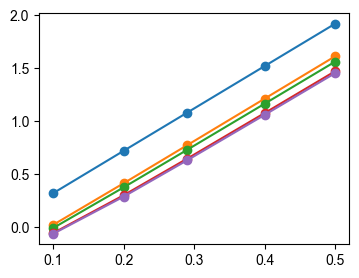

In [543]:
xxx=np.array((0.1,   0.2,   0.29, 0.4,0.5))
yyy00=np.array((0.3185, 0.7188, 1.0789,1.519,1.9191))
yyy0=np.array((0.0196,0.41235,0.7713,1.21113,1.6112))
yyy=np.array((-0.0105,   0.3735,   0.7277, 1.1633,1.560565))
yyy2 = np.array((-0.0585,0.299,0.644,1.075,1.47))
yyy3 = np.array((-0.065,0.286,0.6288,1.058,1.4523))
fig,ax=plt.subplots(figsize=(4,3))
ax.plot(xxx,yyy00,'o-')
ax.plot(xxx,yyy0,'o-')
ax.plot(xxx,yyy,'o-')
ax.plot(xxx,yyy2,'o-')
ax.plot(xxx,yyy3,'o-')

xfit,yfit,popt,perr = dr.fitLinear(xxx,yyy00)
print(popt/4)
xfit,yfit,popt,perr = dr.fitLinear(xxx,yyy0)
print(popt/4)
xfit,yfit,popt,perr = dr.fitLinear(xxx,yyy)
print(popt/4)
xfit,yfit,popt,perr = dr.fitLinear(xxx,yyy2)
print(popt/4)
xfit,yfit,popt,perr = dr.fitLinear(xxx,yyy3)
print(popt/4)
# ax.set_yscale('log')

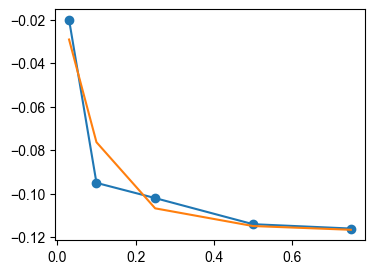

In [573]:
omega = np.array((0.03,0.1,0.25,0.5,0.75))
offset = np.array((-0.02,-0.095,-0.102,-0.114,-0.116))
fig,ax=plt.subplots(figsize=(4,3))
ax.plot(omega,offset,'o-')
# ax.plot(omega,0.003/omega-0.122)
a=0.118
ax.plot(omega,-a*omega/np.sqrt(omega**2 + a**2))

In [8]:
chi2 = np.sum(result.residual**2)
dof = len(y) + len(y0) + len(y2) - len(params)
reduced_chi2 = chi2 
print(f"Reduced χ²: {reduced_chi2:.3f}")

Reduced χ²: 0.000


In [ ]:
# fig.savefig('C:/Users/lukin2dmaterials/data/forDeliv/figs/fig4_corrQME.png', dpi=1200)
# fig.savefig('C:/Users/lukin2dmaterials/data/forDeliv/figs/fig4_corrQME.svg', format='svg')

In [32]:
fitted_params
fitted_params_err

array([0.00467226, 0.12540272, 0.5278701 , 0.64575317, 0.47562553])

[371.03033437 518.00805566  58.96966531]


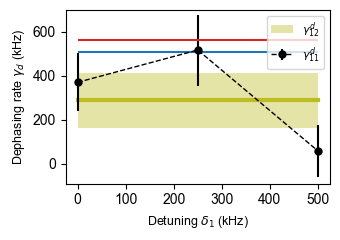

In [15]:
xdummy = np.array([0, 250, 500])
fig,ax=plt.subplots(figsize=(3.5,2.5))
gdtil = fitted_params[2:]/4*1e3; gdtil_err = fitted_params_err[2:]/4*1e3
gdtil = 2*gdtil-gdtil[0]
print(gdtil)

gd12 = fitted_params[1]*np.ones(3)*1e3; gd12_err = fitted_params_err[1]*np.ones(3)*1e3
ax.fill_between(xdummy, gd12-gd12_err, gd12+gd12_err, color="C8", 
                alpha=0.4,linewidth=0,label='$\gamma^d_{12}$')
ax.plot(xdummy, gd12, color="C8", linewidth=3)

ax.errorbar(xdummy, gdtil, gdtil_err, marker='o',linestyle='--',
            linewidth=1, elinewidth=1.5,markersize=5,color='k',label='$\gamma^d_{11}$')
ax.hlines(y=1/1.96*1000,xmin=0,xmax=500,linestyle='-',color='C0')
ax.hlines(y=1/1.77*1000,xmin=0,xmax=500,linestyle='-',color='C3')
    
ax.set_xlabel('Detuning $\delta_1$ (kHz)', fontsize=9)
ax.set_ylabel('Dephasing rate $\gamma_d$ (kHz)', fontsize=9)
ax.legend(fontsize=8)

ax.set_ylim(-0.09*1e3,0.7*1e3)
plt.tight_layout()

In [17]:
gd12

array([290.00000006, 290.00000006, 290.00000006])

In [16]:
gdtil

array([371.03033437, 518.00805566,  58.96966531])

In [ ]:
# fig.savefig('C:/Users/lukin2dmaterials/data/forDeliv/figs/figS10_gamma_d.png', dpi=1200)
# fig.savefig('C:/Users/lukin2dmaterials/data/forDeliv/figs/figS10_gamma_d.svg', format='svg')

### For deliv

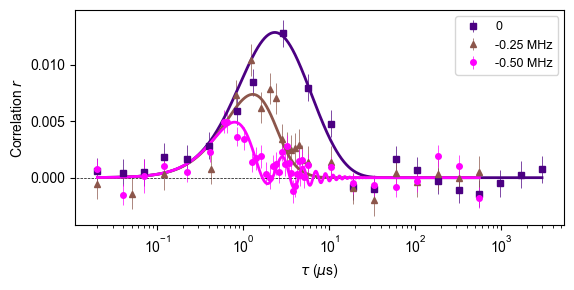

In [10]:
fig, ax = plt.subplots(figsize=(6,3)); ifAntiCorr=1; idx=7; ifFit=0

ax.errorbar(x0,y0,err0, marker='s',linewidth=0.0, elinewidth=0.5,
                markersize=4, label='0',color="#4B0082")
ax.errorbar(x,y,err, marker='^',linewidth=0.0, elinewidth=0.5,
                markersize=4, label='-0.25 MHz',color="C5")
ax.errorbar(x2,y2,err2, marker='o',linewidth=0.0, elinewidth=0.5,
                markersize=4, label='-0.50 MHz',color="magenta")
ax.hlines(y=0,xmin=0,xmax=max(x0),linestyle='--',color='k',linewidth=0.5)
ax.plot(xt0, yt0, linewidth=2, markersize=3, color="#4B0082",label=None)
ax.plot(xt, yt, linewidth=2, markersize=3, color='C5',label=None)
ax.plot(xt2, yt2, linewidth=2, markersize=3, color='magenta',label=None)

ax.set_xscale('log')
# ax.set_xlim((-0.2,6.2))
ax.set_xlabel('$\\tau$ ($\mu$s)')
ax.set_ylabel('Correlation $r$')
ax.legend(fontsize=9,loc='upper right')

plt.tight_layout()

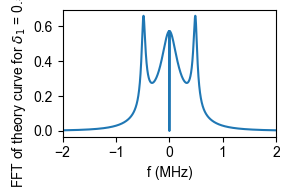

In [12]:
xt2linear = np.linspace(0, 4e3, 400001)
yt2linear = f2(xt2linear,A,gdc, gd12)
# fig,ax=plt.subplots()
# ax.plot(xt2linear, yt2linear)
# ax.set_xscale('log')

def fourier(y, delta_t, f_factor=1):
    yfourier = np.fft.fft(y-np.average(y)); yfourier = np.abs(yfourier)
    f = np.fft.fftfreq(len(y), delta_t)/f_factor  # insert spacing

    sorted_indices = np.argsort(f)       # Get the indices that would sort f
    f = f[sorted_indices]                # Sort f in ascending order
    yfourier = yfourier[sorted_indices]  # Reorder yfourier based on the sorted_indices

    return f,yfourier

f, yf = fourier(yt2linear, 4e3/4e5)
fig,ax=plt.subplots(figsize=(3,2))
ax.plot(f, yf)
ax.set_xlim((-2,2))
ax.set_xlabel('f (MHz)')
ax.set_ylabel('FFT of theory curve for $\delta_1$ = 0.5 MHz')

plt.tight_layout()

In [ ]:
# fig.savefig('C:/Users/lukin2dmaterials/data/forDeliv/figs/fig4_corr2QME.png', dpi=1200)
# fig.savefig('C:/Users/lukin2dmaterials/data/forDeliv/figs/fig4_corr2QME.svg', format='svg')

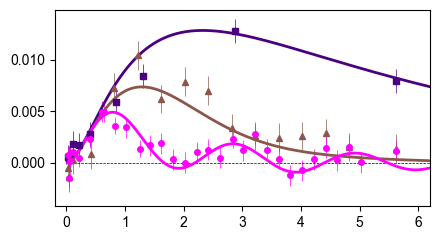

In [13]:
fig, ax = plt.subplots(figsize=(4.5,2.5)); ifAntiCorr=1; idx=7; ifFit=0

ax.errorbar(x0,y0,err0, marker='s',linewidth=0.0, elinewidth=0.5,
                markersize=4, label='0',color="#4B0082")
ax.errorbar(x,y,err, marker='^',linewidth=0.0, elinewidth=0.5,
                markersize=4, label='-0.13 MHz',color="C5")
ax.errorbar(x2,y2,err2, marker='o',linewidth=0.0, elinewidth=0.5,
                markersize=4, label='-0.38 MHz',color="magenta")
ax.hlines(y=0,xmin=0,xmax=max(x0),linestyle='--',color='k',linewidth=0.5)
ax.plot(xt0, yt0, linewidth=2, markersize=3, color="#4B0082",label=None)
ax.plot(xt, yt, linewidth=2, markersize=3, color='C5',label=None)
ax.plot(xt2, yt2, linewidth=2, markersize=3, color='magenta',label=None)

# ax.set_xscale('log')
ax.set_xlim((-0.2,6.2))
# ax.set_xlabel('$\\tau$ ($\mu$s)')
# ax.set_ylabel('Correlation $r$')
# ax.legend(fontsize=9,loc='upper right')

plt.tight_layout()

In [ ]:
# fig.savefig('C:/Users/lukin2dmaterials/data/forDeliv/figs/fig4_corr3QME.png', dpi=1200)
# fig.savefig('C:/Users/lukin2dmaterials/data/forDeliv/figs/fig4_corr3QME.svg', format='svg')

In [ ]:
def f(t_eval, A, Gamma_tot_db, gamma_d_12):
    #Parameters
    delta_1z = 0.25*2*pi #detuning on NV_1
    delta_2z = 0*2*pi #detuning on NV_2
    phi = -pi/2
    amp_1 = 1.012 * np.exp(1j * phi)#using the same notations as in single_qubit simulations
    amp_2 = 1.115 * np.exp(1j * phi)#using the same notations as in single_qubit simulations
    tau_c = 0.1; Gamma_tot_d = Gamma_tot_db

    Gamma_1 = 2 * (2 * np.pi)**0.5 * tau_c * np.abs(amp_1)**2
    Gamma_2 = 2 * (2 * np.pi)**0.5 * tau_c * np.abs(amp_2)**2

    Gamma_tot_r = Gamma_1 + Gamma_2
    Gamma_tot = Gamma_tot_r + Gamma_tot_d

    Mat = np.array([[- Gamma_tot_r, 2 * np.sqrt(Gamma_1 * Gamma_2), 0, 0, 0],
                    [2 * np.sqrt(Gamma_1 * Gamma_2), - Gamma_tot,  4 * gamma_d_12, delta_1z, delta_2z],
                    [0, 4 * gamma_d_12, - Gamma_tot_d, - delta_2z, - delta_1z],
                    [0, - delta_1z, delta_2z, - (Gamma_2 + Gamma_tot_d), - 4 * gamma_d_12],
                    [0, - delta_2z, delta_1z, - 4 * gamma_d_12, - (Gamma_1 + Gamma_tot_d)]])

    eigenvalues, eigenvectors = np.linalg.eig(Mat)
    normalized_eigenvectors = eigenvectors / np.linalg.norm(eigenvectors, axis=0)
    initial_vector = np.array([1, 0, 0, 0, 0])
    coefficients = np.linalg.inv(normalized_eigenvectors).dot(initial_vector)

    analytical = coefficients[0] * np.exp(eigenvalues[0] * t_eval) * normalized_eigenvectors[0, 0] +\
        coefficients[1] * np.exp(eigenvalues[1] * t_eval) * normalized_eigenvectors[0, 1] +\
        coefficients[2] * np.exp(eigenvalues[2] * t_eval) * normalized_eigenvectors[0, 2] +\
        coefficients[3] * np.exp(eigenvalues[3] * t_eval) * normalized_eigenvectors[0, 3] +\
        coefficients[4] * np.exp(eigenvalues[4] * t_eval) * normalized_eigenvectors[0, 4] -\
        np.exp(- (Gamma_1 + Gamma_2) * t_eval)
    # print('done f')
    return A*analytical.real

def f0(t_eval, A, Gamma_tot_da, gamma_d_12):
    #Parameters
    # A=0.05
    delta_1z = 0*2*pi #detuning on NV_1
    delta_2z = 0*2*pi #detuning on NV_2
    phi = -pi/2
    amp_1 = 1.012 * np.exp(1j * phi)#using the same notations as in single_qubit simulations
    amp_2 = 1.115 * np.exp(1j * phi)#using the same notations as in single_qubit simulations
    tau_c = 0.1; Gamma_tot_d=Gamma_tot_da

    Gamma_1 = 2 * (2 * np.pi)**0.5 * tau_c * np.abs(amp_1)**2
    Gamma_2 = 2 * (2 * np.pi)**0.5 * tau_c * np.abs(amp_2)**2

    Gamma_tot_r = Gamma_1 + Gamma_2
    Gamma_tot = Gamma_tot_r + Gamma_tot_d

    Mat = np.array([[- Gamma_tot_r, 2 * np.sqrt(Gamma_1 * Gamma_2), 0, 0, 0],
                    [2 * np.sqrt(Gamma_1 * Gamma_2), - Gamma_tot,  4 * gamma_d_12, delta_1z, delta_2z],
                    [0, 4 * gamma_d_12, - Gamma_tot_d, - delta_2z, - delta_1z],
                    [0, - delta_1z, delta_2z, - (Gamma_2 + Gamma_tot_d), - 4 * gamma_d_12],
                    [0, - delta_2z, delta_1z, - 4 * gamma_d_12, - (Gamma_1 + Gamma_tot_d)]])

    eigenvalues, eigenvectors = np.linalg.eig(Mat)
    normalized_eigenvectors = eigenvectors / np.linalg.norm(eigenvectors, axis=0)
    initial_vector = np.array([1, 0, 0, 0, 0])
    coefficients = np.linalg.inv(normalized_eigenvectors).dot(initial_vector)

    analytical = coefficients[0] * np.exp(eigenvalues[0] * t_eval) * normalized_eigenvectors[0, 0] +\
        coefficients[1] * np.exp(eigenvalues[1] * t_eval) * normalized_eigenvectors[0, 1] +\
        coefficients[2] * np.exp(eigenvalues[2] * t_eval) * normalized_eigenvectors[0, 2] +\
        coefficients[3] * np.exp(eigenvalues[3] * t_eval) * normalized_eigenvectors[0, 3] +\
        coefficients[4] * np.exp(eigenvalues[4] * t_eval) * normalized_eigenvectors[0, 4] -\
        np.exp(- (Gamma_1 + Gamma_2) * t_eval)
    # print('done f0')
    return A*analytical.real

def f2(t_eval, A, Gamma_tot_dc, gamma_d_12):
    #Parameters
    # A=0.04
    delta_1z = 0.5*2*pi #detuning on NV_1
    delta_2z = 0*2*pi #detuning on NV_2
    phi = -pi/2
    amp_1 = 1.012 * np.exp(1j * phi)#using the same notations as in single_qubit simulations
    amp_2 = 1.115 * np.exp(1j * phi)#using the same notations as in single_qubit simulations
    tau_c = 0.1; Gamma_tot_d=Gamma_tot_dc

    Gamma_1 = 2 * (2 * np.pi)**0.5 * tau_c * np.abs(amp_1)**2
    Gamma_2 = 2 * (2 * np.pi)**0.5 * tau_c * np.abs(amp_2)**2

    Gamma_tot_r = Gamma_1 + Gamma_2
    Gamma_tot = Gamma_tot_r + Gamma_tot_d

    Mat = np.array([[- Gamma_tot_r, 2 * np.sqrt(Gamma_1 * Gamma_2), 0, 0, 0],
                    [2 * np.sqrt(Gamma_1 * Gamma_2), - Gamma_tot,  4 * gamma_d_12, delta_1z, delta_2z],
                    [0, 4 * gamma_d_12, - Gamma_tot_d, - delta_2z, - delta_1z],
                    [0, - delta_1z, delta_2z, - (Gamma_2 + Gamma_tot_d), - 4 * gamma_d_12],
                    [0, - delta_2z, delta_1z, - 4 * gamma_d_12, - (Gamma_1 + Gamma_tot_d)]])

    eigenvalues, eigenvectors = np.linalg.eig(Mat)
    normalized_eigenvectors = eigenvectors / np.linalg.norm(eigenvectors, axis=0)
    initial_vector = np.array([1, 0, 0, 0, 0])
    coefficients = np.linalg.inv(normalized_eigenvectors).dot(initial_vector)

    analytical = coefficients[0] * np.exp(eigenvalues[0] * t_eval) * normalized_eigenvectors[0, 0] +\
        coefficients[1] * np.exp(eigenvalues[1] * t_eval) * normalized_eigenvectors[0, 1] +\
        coefficients[2] * np.exp(eigenvalues[2] * t_eval) * normalized_eigenvectors[0, 2] +\
        coefficients[3] * np.exp(eigenvalues[3] * t_eval) * normalized_eigenvectors[0, 3] +\
        coefficients[4] * np.exp(eigenvalues[4] * t_eval) * normalized_eigenvectors[0, 4] -\
        np.exp(- (Gamma_1 + Gamma_2) * t_eval)
    # print('done f2')
    # print(analytical.real)
    return A*analytical.real

# Define objective function
def objective(params, t_eval0, t_eval, t_eval2, y0,y,y2):
    A = params['A'].value
    gd12 = params['gamma_d_12'].value
    gda  = params['Gamma_tot_da'].value
    gdb  = params['Gamma_tot_db'].value
    gdc  = params['Gamma_tot_dc'].value

    # params['gamma_d_12'].max = np.min((gda*0.25, gdb*0.25, gdc*0.281))  # Ensuring b is at least a

    res0 = y0 - f0(t_eval0, A, gda, gd12)
    res  = y -  f(t_eval, A, gdb, gd12)
    res2 = y2 - f2(t_eval2, A, gdc, gd12)
    return np.concatenate((res0, res, res2))  # Combine residuals


### For theory curves in supp

In [18]:
def fthy(t_eval, A, Gamma_tot_da, gamma_d_12):
    #Parameters
    # A=0.05
    delta_1z = 0*2*pi #detuning on NV_1
    delta_2z = 0*2*pi #detuning on NV_2
    phi = -pi/2
    amp_1 = 1.012 * np.exp(1j * phi)#using the same notations as in single_qubit simulations
    amp_2 = 1.012 * np.exp(1j * phi)#using the same notations as in single_qubit simulations
    tau_c = 0.1; Gamma_tot_d=Gamma_tot_da # = 2*(gamma_d11+gamma_d22)

    Gamma_1 = 2 * (2 * np.pi)**0.5 * tau_c * np.abs(amp_1)**2
    Gamma_2 = 2 * (2 * np.pi)**0.5 * tau_c * np.abs(amp_2)**2

    Gamma_tot_r = Gamma_1 + Gamma_2
    Gamma_tot = Gamma_tot_r + Gamma_tot_d

    Mat = np.array([[- Gamma_tot_r, 2 * np.sqrt(Gamma_1 * Gamma_2), 0, 0, 0],
                    [2 * np.sqrt(Gamma_1 * Gamma_2), - Gamma_tot,  4 * gamma_d_12, delta_1z, delta_2z],
                    [0, 4 * gamma_d_12, - Gamma_tot_d, - delta_2z, - delta_1z],
                    [0, - delta_1z, delta_2z, - (Gamma_2 + Gamma_tot_d), - 4 * gamma_d_12],
                    [0, - delta_2z, delta_1z, - 4 * gamma_d_12, - (Gamma_1 + Gamma_tot_d)]])

    eigenvalues, eigenvectors = np.linalg.eig(Mat)
    normalized_eigenvectors = eigenvectors / np.linalg.norm(eigenvectors, axis=0)
    initial_vector = np.array([1, 0, 0, 0, 0])
    coefficients = np.linalg.inv(normalized_eigenvectors).dot(initial_vector)

    analytical = coefficients[0] * np.exp(eigenvalues[0] * t_eval) * normalized_eigenvectors[0, 0] +\
        coefficients[1] * np.exp(eigenvalues[1] * t_eval) * normalized_eigenvectors[0, 1] +\
        coefficients[2] * np.exp(eigenvalues[2] * t_eval) * normalized_eigenvectors[0, 2] +\
        coefficients[3] * np.exp(eigenvalues[3] * t_eval) * normalized_eigenvectors[0, 3] +\
        coefficients[4] * np.exp(eigenvalues[4] * t_eval) * normalized_eigenvectors[0, 4] -\
        np.exp(- (Gamma_1 + Gamma_2) * t_eval)
    # print('done f0')
    return A*analytical.real

In [19]:
phi = -pi/2
amp_1 = 1.012 * np.exp(1j * phi)#using the same notations as in single_qubit simulations
amp_2 = 1.112 * np.exp(1j * phi)#using the same notations as in single_qubit simulations
tau_c = 0.1
Gamma_1 = 2 * (2 * np.pi)**0.5 * tau_c * np.abs(amp_1)**2
Gamma_2 = 2 * (2 * np.pi)**0.5 * tau_c * np.abs(amp_2)**2

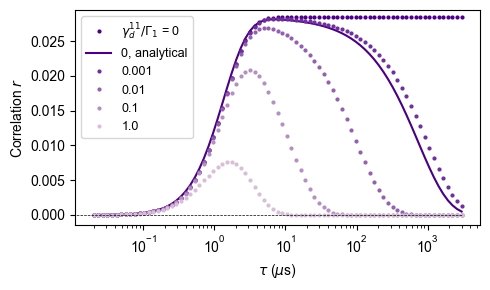

In [578]:
fig, ax = plt.subplots(figsize=(5,3)); ifAntiCorr=1; idx=7; ifFit=0

xt0 = np.logspace(np.log10(x0[0]),np.log10(x0[-1]),81)

ga = Gamma_1 + Gamma_2; gb = 2*np.sqrt(Gamma_1*Gamma_2)
# yanalytic = A*np.exp(-ga*xt0)*(np.cosh(gb*xt0)-1)
gs = ga+gb; gd = ga-gb
yanalytic = A*(0.5*(np.exp(-gs*xt0)+np.exp(-gd*xt0)) - np.exp(-ga*xt0))

start_color = "#4B0082"# Start color: Indigo
end_color = "#D8BFD8" # End color: A faded/lighter version of indigo # Light lavender / thistle (a pale purple)
cmap = mcolors.LinearSegmentedColormap.from_list("faded_gradient", [start_color, end_color], N=5)
colors = [mcolors.to_hex(cmap(i)) for i in np.linspace(0, 1, 5)]

factors = np.array([0, 0.001,0.01,0.1,1])
for i,factor in enumerate(factors):
    ythy = fthy(xt0, A, factor*4*Gamma_1, 0)
    if i==0: label = '$\gamma_d^{11}/\Gamma_1$ = %.0f' % factors[i]
    else: label = factors[i]
    ax.plot(xt0, ythy, 'o-',markersize=2,linewidth=0,color=colors[i],label=label)
    if i==0: ax.plot(xt0, yanalytic, linewidth=1.5, color="#4B0082",label='0, analytical')


ax.hlines(y=0,xmin=0,xmax=max(x0),linestyle='--',color='k',linewidth=0.5)
ax.set_xscale('log')
# ax.set_xlim((-0.2,6.2))
ax.set_xlabel('$\\tau$ ($\mu$s)')
ax.set_ylabel('Correlation $r$')
ax.legend(fontsize=9,loc='upper left')
ax.set_ylim(-0.0015,0.0295)

plt.tight_layout()

In [ ]:
# fig.savefig('C:/Users/lukin2dmaterials/data/forDeliv/figs/figS9_gd11.png', dpi=1200)
# fig.savefig('C:/Users/lukin2dmaterials/data/forDeliv/figs/figS9_gd11.svg', format='svg')

0.0
0.6
0.85
0.95
1.0


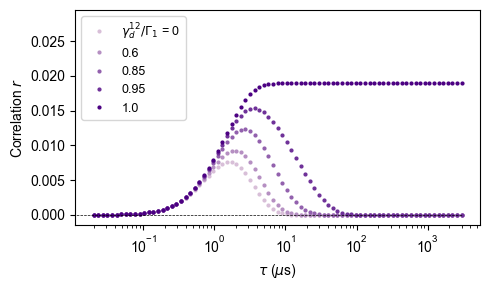

In [579]:
fig, ax = plt.subplots(figsize=(5,3)); ifAntiCorr=1; idx=7; ifFit=0

xt0 = np.logspace(np.log10(x0[0]),np.log10(x0[-1]),81)

ga = Gamma_1 + Gamma_2; gb = 2*np.sqrt(Gamma_1*Gamma_2)
# yanalytic = A*np.exp(-ga*xt0)*(np.cosh(gb*xt0)-1)
gs = ga+gb; gd = ga-gb
yanalytic = A*(0.5*(np.exp(-gs*xt0)+np.exp(-gd*xt0)) - np.exp(-ga*xt0))

# Start color: Indigo
start_color = "#4B0082"
end_color = "#D8BFD8"  
cmap = mcolors.LinearSegmentedColormap.from_list("faded_gradient", [start_color, end_color], N=5)
colors = [mcolors.to_hex(cmap(i)) for i in np.linspace(0, 1, 5)]
colors = colors[::-1]

factors = np.array([0,0.6,0.85,0.95,1])
for i,factor in enumerate(factors):
    print(factor)
    ythy = fthy(xt0, A, 4*Gamma_1, factor*Gamma_1)
    # ythy = fthy(xt0, A, factor*4*Gamma_1, 0)
    if i==0: label = '$\gamma_d^{12}/\Gamma_1$ = %.0f' % factors[i]
    else: label = factors[i]
    ax.plot(xt0, ythy, 'o-',markersize=2,linewidth=0,color=colors[i],label=label)
# ax.plot(xt0, yanalytic, linewidth=1.5, linestyle='--', color="k",label='$\gamma_d^{12}=\gamma_d^{11}=0$')


ax.hlines(y=0,xmin=0,xmax=max(x0),linestyle='--',color='k',linewidth=0.5)
ax.set_xscale('log')
# ax.set_xlim((-0.2,6.2))
ax.set_xlabel('$\\tau$ ($\mu$s)')
ax.set_ylabel('Correlation $r$')
ax.legend(fontsize=9,loc='upper left')
ax.set_ylim(-0.0015,0.0295)

plt.tight_layout()

In [ ]:
# fig.savefig('C:/Users/lukin2dmaterials/data/forDeliv/figs/figS9_gd12.png', dpi=1200)
# fig.savefig('C:/Users/lukin2dmaterials/data/forDeliv/figs/figS9_gd12.svg', format='svg')

In [582]:
y

array([2.04996534e-04, 2.75247884e-04, 3.69380542e-04, 4.95405014e-04,
       6.63958972e-04, 8.89135779e-04, 1.18955599e-03, 1.58974291e-03,
       2.12187282e-03, 2.82797779e-03, 3.76268122e-03, 4.99653834e-03,
       6.62002855e-03, 8.74819404e-03, 1.15258243e-02, 1.51329330e-02,
       1.97900411e-02, 2.57624513e-02, 3.33622644e-02, 4.29463621e-02,
       5.49080239e-02, 6.96593856e-02, 8.76018156e-02, 1.09081840e-01,
       1.34331914e-01, 1.63398587e-01, 1.96065559e-01, 2.31785505e-01,
       2.69640654e-01, 3.08355470e-01, 3.46381432e-01, 3.82060778e-01,
       4.13852885e-01, 4.40579193e-01, 4.61621877e-01, 4.77011746e-01,
       4.87369628e-01, 4.93715664e-01, 4.97210390e-01, 4.98914451e-01,
       4.99637228e-01, 4.99898370e-01, 4.99976795e-01, 4.99995821e-01,
       4.99999429e-01, 4.99999943e-01, 4.99999996e-01, 5.00000000e-01,
       5.00000000e-01, 5.00000000e-01, 5.00000000e-01, 5.00000000e-01,
       5.00000000e-01, 5.00000000e-01, 5.00000000e-01, 5.00000000e-01,
      

C:\Users\lukin2dmaterials\AppData\Local\Temp\ipykernel_109988\90724170.py:2: RuntimeWarning: overflow encountered in cosh
  y = np.exp(-2*g1*x)*(np.cosh(2*x*g1)-1)
C:\Users\lukin2dmaterials\AppData\Local\Temp\ipykernel_109988\90724170.py:2: RuntimeWarning: invalid value encountered in multiply
  y = np.exp(-2*g1*x)*(np.cosh(2*x*g1)-1)
C:\Users\lukin2dmaterials\AppData\Local\Temp\ipykernel_109988\90724170.py:7: RuntimeWarning: divide by zero encountered in log
  -1/2/x*np.log(1-np.sqrt(2*y))


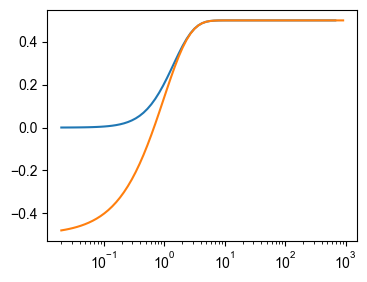

In [605]:
x =xt0[:-8]; g1=0.51
y = np.exp(-2*g1*x)*(np.cosh(2*x*g1)-1)
y2 = (1-2*np.exp(-2*g1*x)+0*np.exp(-4*g1*x))/2
fig,ax=plt.subplots(figsize=(4,3))
ax.plot(x,y)
ax.plot(x,y2)
-1/2/x*np.log(1-np.sqrt(2*y))
ax.set_xscale('log')